**In this notebook we will take a sample of the data and label them in order to use this labeled sample to evaluate our algorithms.**

**I hide the cells that we don't need to run again**

In [1]:
# Import libraries
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import torch
from torchvision import models, transforms
from tqdm import tqdm
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Read data
df = pd.read_json('sneakers_sample_19062025.txt', lines=False)

print(df.head())

                                                data  \
0  {'EAN': [], 'size': '44', 'brand': 'ASICS', 'c...   
1  {'EAN': [], 'size': '44', 'brand': 'VANS', 'co...   
2  {'EAN': [], 'size': '44.5', 'brand': 'ADIDAS',...   
3  {'EAN': [], 'size': '42', 'brand': 'NIKE', 'co...   
4  {'EAN': [], 'size': '11/EU 46', 'brand': 'PUMA...   

                      mirakl_product_id             creation_date  \
0  d96975c5-0bea-41f6-a4a8-fdac53f374f3  2024-01-09T12:09:20.568Z   
1  6f302b78-9a86-484e-894f-bb39220931a3  2023-11-09T13:08:33.276Z   
2  70006973-aa9f-4176-9f38-0ba2c5a1b06f  2025-03-29T08:43:47.421Z   
3  6b010b1d-7475-44dc-ad56-502769d2e742  2024-01-04T12:29:59.343Z   
4  cf04d217-bfd6-4743-ae4b-bc98712959ca  2025-02-13T14:31:57.524Z   

                update_date                           product_sku  \
0  2024-11-06T13:03:01.469Z  d96975c5-0bea-41f6-a4a8-fdac53f374f3   
1  2025-02-12T12:21:44.083Z  6f302b78-9a86-484e-894f-bb39220931a3   
2  2025-03-30T21:07:23.464Z  70006973-aa9

In [3]:
df.shape

(5823, 12)

In [4]:
# take a random sample of the data
df_sample = df.sample(n=1000, random_state=42)

In [5]:
#create separate dataframes

# Create separate dataframes
meta_rows = []
data_rows = []
sources_rows = []

# Exclude some fields that are not necessary for our tasks
exclude_fields = {
    'creation_date', 'update_date',
    'validation', 'synchronization',
    'catalogs', 'selling_authorization', "product_urls"
}

# Convert df_sample to list-of-dicts
records = df_sample.to_dict(orient='records')

for entry in records:
    # Top-level fields (excluding 'data' and 'sources')
    meta = {
        key: entry[key] for key in entry
        if key not in exclude_fields and key not in ['data', 'sources']
    }
    meta_rows.append(meta)
    
    # Extract nested fields
    if 'data' in entry and isinstance(entry['data'], dict):
        data_rows.append(entry['data'])
    if 'sources' in entry and isinstance(entry['sources'], list):
        for source in entry['sources']:
            source['mirakl_product_id'] = entry.get('mirakl_product_id')
            sources_rows.append(source)

# Convert to DataFrames
df_meta = pd.DataFrame(meta_rows)
df_data = pd.json_normalize(data_rows)
df_sources = pd.DataFrame(sources_rows)

In [6]:
df_data.head()

,EAN,size,brand,color,category,heelType,shoeType,shoeWidth,heelHeight,returnable,...,secondary_image_1.original_url,secondary_image_2.source,secondary_image_2.original_url,secondary_image_3.source,secondary_image_3.original_url,longDescription [en_GB],fashionMaterial,name,longDescription,shortDescription
0,[4099758170468],37,KANGAROOS,NEON PINK / FROST PINK,FaWoShSneakers,flat,0020,medium,lowHeel,true,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,[5299900765088],38,ADIDAS,White,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,https://powersoft365customers.blob.core.window...,https://media-prod-eu-1.mirakl.net/SOURCE/7718...,https://powersoft365customers.blob.core.window...,https://media-prod-eu-1.mirakl.net/SOURCE/61ba...,https://powersoft365customers.blob.core.window...,NaN,NaN,NaN,NaN,NaN
2,[],44,NEW BALANCE,Black,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,https://administrator.athlokinisi.com.cy/produ...,https://media-prod-eu-1.mirakl.net/SOURCE/b91b...,https://administrator.athlokinisi.com.cy/produ...,https://media-prod-eu-1.mirakl.net/SOURCE/39d8...,https://administrator.athlokinisi.com.cy/produ...,NaN,NaN,NaN,NaN,NaN
3,[],46,UNDER ARMOUR,Black,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,https://privesports.com.cy/product_catalog/gro...,https://media-prod-eu-1.mirakl.net/SOURCE/b78c...,https://privesports.com.cy/product_catalog/gro...,https://media-prod-eu-1.mirakl.net/SOURCE/a11e...,https://privesports.com.cy/product_catalog/gro...,NaN,NaN,NaN,NaN,NaN
4,[],39.5,SKECHERS,Black,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,https://powersoft365customers.blob.core.window...,https://media-prod-eu-1.mirakl.net/SOURCE/17ff...,https://powersoft365customers.blob.core.window...,https://media-prod-eu-1.mirakl.net/SOURCE/e18d...,https://powersoft365customers.blob.core.window...,NaN,NaN,NaN,NaN,NaN


In [7]:
df_data.columns

Index(['EAN', 'size', 'brand', 'color', 'category', 'heelType', 'shoeType',
       'shoeWidth', 'heelHeight', 'returnable', 'name [el_CY]', 'name [en_GB]',
       'updateOnDelta', 'refinementColor', 'variantGroupCode',
       'jiniusSkuMatchCode', 'longDescription [el_CY]',
       'shortDescription [en_GB]', 'mainImage.source',
       'mainImage.original_url', 'shortDescription [el_CY]',
       'secondary_image_1.source', 'secondary_image_1.original_url',
       'secondary_image_2.source', 'secondary_image_2.original_url',
       'secondary_image_3.source', 'secondary_image_3.original_url',
       'longDescription [en_GB]', 'fashionMaterial', 'name', 'longDescription',
       'shortDescription'],
      dtype='object')

In [8]:
# check that each product has a unique mirakl_product_id
df_meta['mirakl_product_id'].nunique()

1000

In [9]:
# Add mirakl_product_id df_data, in order to be able to match image embeddings back to the corresponding product
df_data = pd.concat([
    df_data.reset_index(drop=True),
    df_meta[['mirakl_product_id']].reset_index(drop=True)
], axis=1)

In [10]:
df_data.columns

Index(['EAN', 'size', 'brand', 'color', 'category', 'heelType', 'shoeType',
       'shoeWidth', 'heelHeight', 'returnable', 'name [el_CY]', 'name [en_GB]',
       'updateOnDelta', 'refinementColor', 'variantGroupCode',
       'jiniusSkuMatchCode', 'longDescription [el_CY]',
       'shortDescription [en_GB]', 'mainImage.source',
       'mainImage.original_url', 'shortDescription [el_CY]',
       'secondary_image_1.source', 'secondary_image_1.original_url',
       'secondary_image_2.source', 'secondary_image_2.original_url',
       'secondary_image_3.source', 'secondary_image_3.original_url',
       'longDescription [en_GB]', 'fashionMaterial', 'name', 'longDescription',
       'shortDescription', 'mirakl_product_id'],
      dtype='object')

### **Step 1: Group based on identical images**

It has been observed that some products, despite being identical, are under differnt names (for example *Air 1 low 85* and *Nike Air jordan 1 low 85*). In this first step, we vectorize the images of the products and update the groups for the products that have idenctical images.  

Detailed steps:
1. Extract image embeddings for all images in the dataframe (using ResNet, specifically pretrained ResNet50)
2. Preprocess images (resize to 224x224, normalize with ImageNet mean and std)
3. Compute pairwise similarity (cosine similarity of embeddings)
4. Identify high similarity pairs from different groups (threshold very high, e.g. 0.99 to approximate "same image")
5. Build connected components graph: products connected via identical images
6. Assign a group ID (same ID for all connected items)

#### **No need to run again the following, since we have saved the embeddings and corresponding image ids**

In [11]:
# # Standard image preprocessing for ResNet
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),
# ])

# # load pretrained model
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# model = models.resnet18(pretrained=True)
# model = torch.nn.Sequential(*list(model.children())[:-1])  # remove final classifier
# model.eval()
# model.to(device)

In [12]:
# # define function to try URLs in priority order
# def try_load_image(row):
#     urls = [
#         row.get('mainImage.original_url'),
#         row.get('secondary_image_1.original_url'),
#         row.get('secondary_image_2.original_url'),
#     ]
#     for url in urls:
#         if pd.isna(url) or not isinstance(url, str):
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             if response.status_code == 200:
#                 img = Image.open(BytesIO(response.content)).convert('RGB')
#                 return img
#         except Exception:
#             continue
#     return None  # all failed

In [13]:
# # extract all images
# images = []
# product_ids = []

# for idx, row in tqdm(df_data.iterrows(), total=len(df_data)):
#     img = try_load_image(row)
#     if img is not None:
#         images.append(img)
#         product_ids.append(row['mirakl_product_id'])

In [14]:
# # vectorize images
# all_embeddings = []

# with torch.no_grad():
#     for img in tqdm(images):
#         input_tensor = transform(img).unsqueeze(0).to(device)
#         embedding = model(input_tensor).squeeze().cpu().numpy().flatten()
#         all_embeddings.append(embedding)
        
# all_embeddings = np.vstack(all_embeddings)
# product_ids = list(product_ids)

In [15]:
# # Save embeddings and corresponding IDs
# np.save("image_embeddings_sample.npy", np.stack(all_embeddings))
# pd.Series(product_ids).to_csv("image_ids_sample.csv", index=False)

In [16]:
# load them
all_embeddings = np.load("image_embeddings_sample.npy")
product_ids = pd.read_csv("image_ids_sample.csv").iloc[:, 0].tolist()

In [17]:
# identify identical images
threshold = 0.97
sim_matrix = cosine_similarity(all_embeddings)
adjacency = (sim_matrix >= threshold).astype(int)
graph = csr_matrix(adjacency)
n_components, labels = connected_components(csgraph=graph, directed=False, return_labels=True)

In [18]:
# assign group ids to df_data
group_df = pd.DataFrame({
    'mirakl_product_id': product_ids,
    'group_id1': labels
})

df_data = df_data.merge(group_df, how='left', on='mirakl_product_id')

In [19]:
df_data["group_id1"].nunique()

915

Many of the products have effectively been grouped. Following we display the images of some groups as a first visual test of the grouping. For **similarity threshold of 0.95** I observed that the groups are not good. For **similarity threshold of 0.97** I observe that the displayed groups include the variants and are correct. Since the largest groups do not include different products, I assume that smaller groups are very likely not to include different products as well.

In [20]:
# # --------------- 1. Identify the 10 largest groups ----------------

# # Count group sizes
# group_counts = df_data['group_id1'].value_counts()

# # Get top 10 largest groups
# top_10_groups = group_counts.head(10).index.tolist()

# print("Top 10 largest group IDs:", top_10_groups)


# # --------------- 2. Filter to those groups ----------------

# df_subset = df_data[df_data['group_id1'].isin(top_10_groups)].copy()


# # --------------- 3. Define helper to get first available image URL ----------------

# def get_best_image_url(row):
#     urls = [
#         row.get('mainImage.original_url'),
#         row.get('secondary_image_1.original_url'),
#         row.get('secondary_image_2.original_url'),
#     ]
#     for url in urls:
#         if pd.isna(url) or not isinstance(url, str) or url.strip() == '':
#             continue
#         return url
#     return None


# # Add new column for selected URL
# df_subset['selected_image_url'] = df_subset.apply(get_best_image_url, axis=1)


# # --------------- 4. Display images in grid ----------------

# for group_id1 in top_10_groups:
#     group_products = df_subset[df_subset['group_id1'] == group_id1]
#     print(f"\nGroup ID: {group_id1}  ({len(group_products)} products)")

#     n_images = len(group_products)
#     max_display = min(10, n_images)   # Show up to 10 per group

#     n_cols = 5
#     n_rows = (max_display + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, group_products.iterrows()):
#         url = row['selected_image_url']
#         if url is None:
#             ax.set_title('No Image', fontsize=8)
#             ax.axis('off')
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             img = Image.open(BytesIO(response.content))
#             ax.imshow(img)
#             ax.set_title(str(row['mirakl_product_id']), fontsize=8)
#             ax.axis('off')
#         except Exception as e:
#             print(f"Error loading image for ID {row['mirakl_product_id']}: {e}")
#             ax.set_title('Error', fontsize=8)
#             ax.axis('off')

#     # Turn off unused axes if group is smaller than grid
#     for ax in axes[max_display:]:
#         ax.axis('off')

#     plt.suptitle(f"Group ID: {group_id1}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

### **Step 2: Further group by name**

From previous exploration on the images, we observed that for several products all three images are broken. Therefore such products cannot be grouped in Step 1. It is also likely that identical products do not have the exact same image (due to the images being provided by multiple merchants). In this second step we will group products based on their names.

In [21]:
# ensure nulls don’t break grouping
df_data['name [en_GB'] = df_data['name [en_GB]'].fillna('')

df_data['group_id2'] = pd.factorize(df_data['name [en_GB]'])[0]

In [22]:
df_data['group_id2'].nunique()

865

In [23]:
df_data['group_id2']

0        0
1        1
2        2
3        3
4        4
      ... 
995    861
996    862
997    464
998    863
999    864
Name: group_id2, Length: 1000, dtype: int64

In [24]:
df_data

,EAN,size,brand,color,category,heelType,shoeType,shoeWidth,heelHeight,returnable,...,secondary_image_3.original_url,longDescription [en_GB],fashionMaterial,name,longDescription,shortDescription,mirakl_product_id,group_id1,name [en_GB,group_id2
0,[4099758170468],37,KANGAROOS,NEON PINK / FROST PINK,FaWoShSneakers,flat,0020,medium,lowHeel,true,...,NaN,NaN,NaN,NaN,NaN,NaN,23855dd1-0ec8-4a9c-8fba-98efa675dc89,NaN,K cr cliff,0
1,[5299900765088],38,ADIDAS,White,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,https://powersoft365customers.blob.core.window...,NaN,NaN,NaN,NaN,NaN,94ef73a2-5f7d-41c5-be54-ae98fbf3b26b,0.0,Adidas advantage base,1
2,[],44,NEW BALANCE,Black,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,https://administrator.athlokinisi.com.cy/produ...,NaN,NaN,NaN,NaN,NaN,532fb849-95c8-4b24-9adf-a98e0bf38807,1.0,Dynasoft nitrel v6 running shoes,2
3,[],46,UNDER ARMOUR,Black,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,https://privesports.com.cy/product_catalog/gro...,NaN,NaN,NaN,NaN,NaN,7cf7ed99-e3af-4538-acee-74d7db6b1e7f,2.0,Charged assert 10,3
4,[],39.5,SKECHERS,Black,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,https://powersoft365customers.blob.core.window...,NaN,NaN,NaN,NaN,NaN,a8238340-ef5a-4a34-9e85-7d7be633307b,3.0,Skechers women duraleather bungee slip,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,[],37,LIU JO,Denim,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,https://administrator.athlokinisi.com.cy/produ...,NaN,NaN,NaN,NaN,NaN,f48fc83d-f40d-49ad-960b-ff0634eed9ed,911.0,Maxi wonder 71 - platform denim and glitter sn...,861
996,[],44,VANS,Navy / White,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,https://administrator.athlokinisi.com.cy/produ...,NaN,NaN,NaN,NaN,NaN,3cdfd24f-785d-4a35-bb8f-4defa199a5d5,912.0,Ultrarange neo vr3 shoes,862
997,[],36.5,CONVERSE,Black,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,https://privesports.com.cy/product_catalog/gro...,NaN,NaN,NaN,NaN,NaN,606031f9-c575-4422-9f19-1708c875252a,473.0,Run star hike canvas platform,464
998,[],42,ADIDAS,Silver,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,https://administrator.athlokinisi.com.cy/produ...,NaN,NaN,NaN,NaN,NaN,29a12d01-a379-40ba-85c7-a9a8d1bcf85d,913.0,4dfwd 2 men,863


### **Step 3: Group based on having almost identical description**

From previous analysis we observed that several identical products have different names (e.g. *Adidas gazelle shoes* and *gazelle shoes* or *Air 1 low 85* and *Nike Air jordan 1 low 85*). In this 3rd step we will group products that have similar descriptions.

In [25]:
# # fill missing values
# df_data['shortDescription [en_GB]'] = df_data['shortDescription [en_GB]'].fillna('')

In [26]:
# # vectorize descriptions using TF-IDF
# vectorizer = TfidfVectorizer(stop_words='english')
# tfidf_matrix = vectorizer.fit_transform(df_data['shortDescription [en_GB]'])

In [27]:
# similarity_matrix = cosine_similarity(tfidf_matrix)

In [28]:
# # define a threshold
# similarity_threshold = 0.999 

# # build adjacency matrix
# adjacency = (similarity_matrix >= similarity_threshold).astype(int)
# np.fill_diagonal(adjacency, 1)  # Ensure self-loops

In [29]:
# # extract connected components
# graph = csr_matrix(adjacency)
# n_components, labels = connected_components(csgraph=graph, directed=False, return_labels=True)

# # group
# df_data['group_id3'] = labels

In [30]:
# df_data['group_id3'].nunique()

Dsiplay the images of the largest groups:

In [31]:
# # --------------- 1. Identify the 10 largest groups by group_id3 ----------------

# # Count group sizes
# group_counts3 = df_data['group_id3'].value_counts()

# # Get top 10 largest groups
# top_10_groups3 = group_counts3.head(10).index.tolist()

# print("Top 10 largest group_id3:", top_10_groups3)


# # --------------- 2. Filter to those groups ----------------

# df_subset3 = df_data[df_data['group_id3'].isin(top_10_groups3)].copy()


# # --------------- 3. Define helper to get first available image URL ----------------

# def get_best_image_url(row):
#     urls = [
#         row.get('mainImage.original_url'),
#         row.get('secondary_image_1.original_url'),
#         row.get('secondary_image_2.original_url'),
#     ]
#     for url in urls:
#         if pd.isna(url) or not isinstance(url, str) or url.strip() == '':
#             continue
#         return url
#     return None


# # Add new column for selected URL
# df_subset3['selected_image_url'] = df_subset3.apply(get_best_image_url, axis=1)


# # --------------- 4. Display images in grid ----------------

# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO

# for group_id in top_10_groups3:
#     group_products = df_subset3[df_subset3['group_id3'] == group_id]
#     print(f"\nGroup ID 3: {group_id}  ({len(group_products)} products)")

#     n_images = len(group_products)
#     max_display = min(10, n_images)   # Show up to 10 per group

#     n_cols = 5
#     n_rows = (max_display + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, group_products.iterrows()):
#         url = row['selected_image_url']
#         if url is None:
#             ax.set_title('No Image', fontsize=8)
#             ax.axis('off')
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             img = Image.open(BytesIO(response.content))
#             ax.imshow(img)
#             ax.set_title(str(row['mirakl_product_id']), fontsize=8)
#             ax.axis('off')
#         except Exception as e:
#             print(f"Error loading image for ID {row['mirakl_product_id']}: {e}")
#             ax.set_title('Error', fontsize=8)
#             ax.axis('off')

#     # Turn off unused axes if group is smaller than grid
#     for ax in axes[max_display:]:
#         ax.axis('off')

#     plt.suptitle(f"Group ID 3: {group_id}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

From the above output we observe that for very high similarity threshold, the groups are not so accurate in some cases. This is due to similar but different products having very similar descriptions. 

### **So we should not use group_id3 in our final grouping!**

## Next step: Final Group ID

- Combine group_id1 and group_id2:
    - Our rule: "if two products match in either group, assign them the same final_group_id".
    - We will use union-find or graph-based merging logic.
    - Avoid group_id3 for now due to false positives.

#### `final_group_id` from `group_id1` and `group_id2`

To compute a **`final_group_id`** that merges products grouped by either **image similarity** (`group_id1`) or **exact name match** (`group_id2`), we will treat this as a **graph problem**:

- Each product is a **node**.
- If two products share the same `group_id1` **or** `group_id2`, we connect them with an **edge**.
- Then we find the **connected components** of this graph—each component represents a cluster of equivalent products.
- The `final_group_id` is simply the **component ID** assigned to each connected group.

This approach ensures that **indirect links** are captured:
> For example, if A matches B by image and B matches C by name, then A, B, and C will all be grouped together—even if A and C don’t match directly.

In [32]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# --- Required: df_data must contain these three columns already ---
# 'mirakl_product_id', 'group_id1', and 'group_id2'

# Step 1: Create index mapping
mirakl_product_id = df_data['mirakl_product_id'].values
group_id1 = df_data['group_id1'].values
group_id2 = df_data['group_id2'].values
n = len(df_data)
adjacency = np.zeros((n, n), dtype=bool)

# Step 2: Link all pairs that share the same group in group_id1 or group_id2
for gid in [group_id1, group_id2]:
    group_map = {}
    for idx, group in enumerate(gid):
        group_map.setdefault(group, []).append(idx)
    for indices in group_map.values():
        for i in indices:
            adjacency[i, indices] = True  # Link all members of the group

# Step 3: Find connected components
graph = csr_matrix(adjacency)
_, final_labels = connected_components(csgraph=graph, directed=False, return_labels=True)

# Step 4: Assign to new column
df_data["final_group_id"] = final_labels

In [33]:
df_data['final_group_id'].nunique()

845

### Evaluate final_group_id

To evaluate the quality of the final_group_id assignments, we will do at first a manual visual inspection. This involves selecting the top 10 largest groups (those with the most products) and visually verifying whether the grouped products are truly the same. The code below:
- Extracts the top 10 most populated final_group_id clusters.
- For each group, selects the best image URL available per product.
- Displays up to 10 product images from each group in a grid format.
- This is to quickly assess if the grouping logic is effective or if further refinement is needed (e.g., incorrect groupings due to overly loose image/name matching).

### Visual Inspection of Final Grouped Products (`final_group_id`)

To assess whether the `final_group_id` clustering is effective, we display the top 10 largest groups and visually inspect them.


In [34]:
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

# 1. Get top 10 largest final groups
top_10_groups = df_data["final_group_id"].value_counts().head(10).index.tolist()
df_subset = df_data[df_data["final_group_id"].isin(top_10_groups)].copy()

# 2. Define function to pick first available image URL
def get_best_image_url(row):
    urls = [
        row.get('mainImage.original_url'),
        row.get('secondary_image_1.original_url'),
        row.get('secondary_image_2.original_url'),
    ]
    for url in urls:
        if pd.isna(url) or not isinstance(url, str) or url.strip() == '':
            continue
        return url
    return None

df_subset["selected_image_url"] = df_subset.apply(get_best_image_url, axis=1)

In [35]:
# # 3. Display up to 10 products per group
# for group_id in top_10_groups:
#     group_products = df_subset[df_subset["final_group_id"] == group_id]
#     print(f"\nFinal Group ID: {group_id} ({len(group_products)} products)")

#     n_images = len(group_products)
#     max_display = min(10, n_images)
#     n_cols = 5
#     n_rows = (max_display + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, group_products.iterrows()):
#         url = row["selected_image_url"]
#         if url is None:
#             ax.set_title("No Image", fontsize=8)
#             ax.axis("off")
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             img = Image.open(BytesIO(response.content))
#             ax.imshow(img)
#             ax.set_title(str(row["mirakl_product_id"]), fontsize=8)
#             ax.axis("off")
#         except Exception as e:
#             print(f"Error loading image for ID {row['mirakl_product_id']}: {e}")
#             ax.set_title("Error", fontsize=8)
#             ax.axis("off")

#     for ax in axes[max_display:]:
#         ax.axis("off")

#     plt.suptitle(f"Final Group ID: {group_id}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

#### after investigating the largest clusters we will see some more since these seem pretty good!

##### Optional Parameters we can control
top_n = 30: Number of clusters we want to visualize.

max_display = 10: Number of products per group to show (can also increase this if needed).

In [36]:
# 1. Get top 10 largest final groups
top_n = 30  # or any number you want
top_n_groups = df_data["final_group_id"].value_counts().head(top_n).index.tolist()

df_subset_n_groups = df_data[df_data["final_group_id"].isin(top_n_groups)].copy()

# 2. Define function to pick first available image URL
def get_best_image_url(row):
    urls = [
        row.get('mainImage.original_url'),
        row.get('secondary_image_1.original_url'),
        row.get('secondary_image_2.original_url'),
    ]
    for url in urls:
        if pd.isna(url) or not isinstance(url, str) or url.strip() == '':
            continue
        return url
    return None

df_subset_n_groups["selected_image_url"] = df_subset_n_groups.apply(get_best_image_url, axis=1)

In [37]:
# # 3. Display up to 10 products per group
# for group_id in top_n_groups:
#     group_products = df_subset_n_groups[df_subset_n_groups["final_group_id"] == group_id]
#     print(f"\nFinal Group ID: {group_id} ({len(group_products)} products)")

#     n_images = len(group_products)
#     max_display = min(10, n_images)
#     n_cols = 5
#     n_rows = (max_display + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, group_products.iterrows()):
#         url = row["selected_image_url"]
#         if url is None:
#             ax.set_title("No Image", fontsize=8)
#             ax.axis("off")
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             img = Image.open(BytesIO(response.content))
#             ax.imshow(img)
#             ax.set_title(str(row["mirakl_product_id"]), fontsize=8)
#             ax.axis("off")
#         except Exception as e:
#             print(f"Error loading image for ID {row['mirakl_product_id']}: {e}")
#             ax.set_title("Error", fontsize=8)
#             ax.axis("off")

#     for ax in axes[max_display:]:
#         ax.axis("off")

#     plt.suptitle(f"Final Group ID: {group_id}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

All clusters seem pretty good except **Final Group ID 352**

- Shoe 1 and Shoe 2 are identical high-top sneakers, just with minor color changes (black vs red detail).
- Shoe 3 looks similar but is actually a low-top variant — a different model in structure.

Yet all three were grouped together because:
- Their images are visually very similar.
- The difference in shoe height (cut) may not be captured well by image embeddings.
- The names/descriptions might also be similar (e.g., “Nike Air Tech Challenge 2” in all).

This is a **false positive**: different variants mistakenly grouped as one model. 

The goal is to only group shoes with the exact same silhouette, so we need stronger filtering?

In [38]:
# Filter and display products from final_group_id 352
df_data[df_data['final_group_id'] == 352][['mirakl_product_id', 'name [en_GB]', 'shortDescription [en_GB]']]

,mirakl_product_id,name [en_GB],shortDescription [en_GB]
375,3b9e27d6-99e5-46ea-ae6b-76293a8c8e0c,Nike Air flight 89,NIKE AIR FLIGHT 89
626,64c642a5-b321-415b-9b73-14f520c83710,Nike Air flight 89,NIKE AIR FLIGHT 89
945,919cee9a-6e3e-4e48-817e-3a813f2d66f9,Nike Air flight 89,NIKE AIR FLIGHT 89


### stricter image-based grouping

This code repeats your image-based grouping process, but with stricter matching — increasing the cosine similarity threshold from 0.97 to 0.985. This reduces false positives by grouping only products whose images are nearly identical.

To prevent overwriting previous results:
- A copy of df_data is created: df_data_strict.

New variables are used:

- image_embeddings_strict

- sim_matrix_strict

- strict_adjacency

- group_id_image_strict

In [39]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# Load image embeddings and product IDs
image_embeddings_strict = np.load("image_embeddings_sample.npy")
product_ids_strict = pd.read_csv("image_ids_sample.csv").iloc[:, 0].tolist()

# Compute cosine similarity with stricter threshold
threshold_strict = 0.985
sim_matrix_strict = cosine_similarity(image_embeddings_strict)
strict_adjacency = (sim_matrix_strict >= threshold_strict).astype(int)
np.fill_diagonal(strict_adjacency, 1)

# Apply connected components to identify image-based clusters
strict_graph = csr_matrix(strict_adjacency)
_, labels_strict = connected_components(csgraph=strict_graph, directed=False, return_labels=True)

# Create DataFrame with new group labels
strict_group_df = pd.DataFrame({
    'mirakl_product_id': product_ids_strict,
    'group_id_image_strict': labels_strict
})

# Make a copy of df_data to preserve the original
df_data_strict = df_data.copy()

# Merge strict group labels into the copy
df_data_strict = df_data_strict.merge(strict_group_df, how='left', on='mirakl_product_id')

# Optional: display sample output
df_data_strict[['mirakl_product_id', 'name [en_GB]', 'group_id1', 'group_id_image_strict']].head()

,mirakl_product_id,name [en_GB],group_id1,group_id_image_strict
0,23855dd1-0ec8-4a9c-8fba-98efa675dc89,K cr cliff,NaN,NaN
1,94ef73a2-5f7d-41c5-be54-ae98fbf3b26b,Adidas advantage base,0.0,0.0
2,532fb849-95c8-4b24-9adf-a98e0bf38807,Dynasoft nitrel v6 running shoes,1.0,1.0
3,7cf7ed99-e3af-4538-acee-74d7db6b1e7f,Charged assert 10,2.0,2.0
4,a8238340-ef5a-4a34-9e85-7d7be633307b,Skechers women duraleather bungee slip,3.0,3.0


In [40]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# 1. Create stricter name-based group using exact name string match
df_data_strict['name_clean'] = df_data_strict['name [en_GB]'].fillna('').str.strip().str.lower()
df_data_strict['group_id_name_strict'] = pd.factorize(df_data_strict['name_clean'])[0]

# 2. Combine group_id_image_strict and group_id_name_strict into final_group_id_strict

# Extract values
mirakl_ids_strict = df_data_strict['mirakl_product_id'].values
group_img_strict = df_data_strict['group_id_image_strict'].values
group_name_strict = df_data_strict['group_id_name_strict'].values
n_strict = len(df_data_strict)

# Build adjacency matrix
adjacency_final_strict = np.zeros((n_strict, n_strict), dtype=bool)

for gid in [group_img_strict, group_name_strict]:
    group_map = {}
    for idx, group in enumerate(gid):
        group_map.setdefault(group, []).append(idx)
    for indices in group_map.values():
        for i in indices:
            adjacency_final_strict[i, indices] = True

# Find connected components
graph_final_strict = csr_matrix(adjacency_final_strict)
_, final_labels_strict = connected_components(csgraph=graph_final_strict, directed=False, return_labels=True)

# 3. Assign final group
df_data_strict['final_group_id_strict'] = final_labels_strict

# Optional preview
df_data_strict[['mirakl_product_id', 'name [en_GB]', 'group_id_image_strict', 'group_id_name_strict', 'final_group_id_strict']].head()

,mirakl_product_id,name [en_GB],group_id_image_strict,group_id_name_strict,final_group_id_strict
0,23855dd1-0ec8-4a9c-8fba-98efa675dc89,K cr cliff,NaN,0,0
1,94ef73a2-5f7d-41c5-be54-ae98fbf3b26b,Adidas advantage base,0.0,1,1
2,532fb849-95c8-4b24-9adf-a98e0bf38807,Dynasoft nitrel v6 running shoes,1.0,2,2
3,7cf7ed99-e3af-4538-acee-74d7db6b1e7f,Charged assert 10,2.0,3,3
4,a8238340-ef5a-4a34-9e85-7d7be633307b,Skechers women duraleather bungee slip,3.0,4,4


In [41]:
# # 1. Get top 10 largest final groups
# top_n = 30  # or any number you want
# top_n_groups = df_data_strict["final_group_id_strict"].value_counts().head(top_n).index.tolist()

# df_subset_n_groups_strict = df_data_strict[df_data_strict["final_group_id_strict"].isin(top_n_groups)].copy()

# # 2. Define function to pick first available image URL
# def get_best_image_url(row):
#     urls = [
#         row.get('mainImage.original_url'),
#         row.get('secondary_image_1.original_url'),
#         row.get('secondary_image_2.original_url'),
#     ]
#     for url in urls:
#         if pd.isna(url) or not isinstance(url, str) or url.strip() == '':
#             continue
#         return url
#     return None

# df_subset_n_groups_strict["selected_image_url"] = df_subset_n_groups_strict.apply(get_best_image_url, axis=1)

# # 3. Display up to 10 products per group
# for group_id in top_n_groups:
#     group_products = df_subset_n_groups_strict[df_subset_n_groups_strict["final_group_id_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} ({len(group_products)} products)")

#     n_images = len(group_products)
#     max_display = min(10, n_images)
#     n_cols = 5
#     n_rows = (max_display + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, group_products.iterrows()):
#         url = row["selected_image_url"]
#         if url is None:
#             ax.set_title("No Image", fontsize=8)
#             ax.axis("off")
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             img = Image.open(BytesIO(response.content))
#             ax.imshow(img)
#             ax.set_title(str(row["mirakl_product_id"]), fontsize=8)
#             ax.axis("off")
#         except Exception as e:
#             print(f"Error loading image for ID {row['mirakl_product_id']}: {e}")
#             ax.set_title("Error", fontsize=8)
#             ax.axis("off")

#     for ax in axes[max_display:]:
#         ax.axis("off")

#     plt.suptitle(f"Final Group ID: {group_id}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

The previously mentioned problematic "Final Group ID" is now the ID 353.

The problem still persists, so we shall try another embedding model?

## Same process different embedding model

CLIP (ViT-B/32) is much stronger than ResNet18 at capturing fine-grained visual differences. We’ll use only its vision encoder to get image embeddings. Then we’ll use cosine similarity and connected components, as before.

- Use a different model — CLIP from OpenAI (vision-language model) for better feature embeddings.

- Redo grouping using a new threshold (0.985) and new variable names to keep everything separate.

- Generate a new merged strict grouping: final_group_id_clip_strict.

In [42]:
# import torch
# from PIL import Image
# from torchvision import transforms
# from transformers import CLIPProcessor, CLIPModel
# import pandas as pd
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity
# from scipy.sparse import csr_matrix
# from scipy.sparse.csgraph import connected_components
# import requests
# from io import BytesIO

# # Load CLIP model
# clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [43]:
df_data_clip = df_data.copy().reset_index(drop=True)

In [44]:
# # Define image loader
# def load_best_image_clip(row):
#     urls = [
#         row.get('mainImage.original_url'),
#         row.get('secondary_image_1.original_url'),
#         row.get('secondary_image_2.original_url'),
#     ]
#     for url in urls:
#         if not url or not isinstance(url, str):
#             continue
#         try:
#             img = Image.open(BytesIO(requests.get(url, timeout=5).content)).convert("RGB")
#             return img
#         except:
#             continue
#     return None

# # Load and embed images using CLIP
# clip_images = []
# clip_ids = []
# for _, row in df_data_clip.iterrows():
#     img = load_best_image_clip(row)
#     if img is not None:
#         inputs = clip_processor(images=img, return_tensors="pt")
#         with torch.no_grad():
#             emb = clip_model.get_image_features(**inputs).squeeze().numpy()
#         clip_images.append(emb)
#         clip_ids.append(row["mirakl_product_id"])

# # Convert to array
# clip_embeddings = np.vstack(clip_images)

In [45]:
# # Save for reuse (optional)
# np.save("clip_embeddings.npy", clip_embeddings)
# pd.DataFrame(clip_ids, columns=["mirakl_product_id"]).to_csv("clip_ids.csv", index=False)

In [46]:
# # Save product IDs to .csv file
# pd.DataFrame(clip_ids, columns=["mirakl_product_id"]).to_csv("clip_ids.csv", index=False)

In [47]:
# Load CLIP image embeddings
clip_embeddings = np.load("clip_embeddings.npy")

# Load product IDs from CSV
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

In [48]:
# Grouping based on CLIP embeddings
clip_sim_matrix = cosine_similarity(clip_embeddings)
clip_threshold = 0.99
clip_adjacency = (clip_sim_matrix >= clip_threshold).astype(int)
np.fill_diagonal(clip_adjacency, 1)

clip_graph = csr_matrix(clip_adjacency)
_, clip_labels = connected_components(csgraph=clip_graph, directed=False, return_labels=True)

# Create CLIP group ID dataframe
clip_group_df = pd.DataFrame({
    'mirakl_product_id': clip_ids,
    'group_id_clip_strict': clip_labels
})

# Merge with df_data_clip
df_data_clip = df_data_clip.merge(clip_group_df, how='left', on='mirakl_product_id')

# Create name-based group
df_data_clip['name_clean_clip'] = df_data_clip['name [en_GB]'].fillna('').str.strip().str.lower()
df_data_clip['group_id_name_clip_strict'] = pd.factorize(df_data_clip['name_clean_clip'])[0]

# Combine into final group
clip_img = df_data_clip['group_id_clip_strict'].values
clip_name = df_data_clip['group_id_name_clip_strict'].values
n = len(df_data_clip)

adjacency_final_clip = np.zeros((n, n), dtype=bool)
for gid in [clip_img, clip_name]:
    group_map = {}
    for idx, group in enumerate(gid):
        group_map.setdefault(group, []).append(idx)
    for indices in group_map.values():
        for i in indices:
            adjacency_final_clip[i, indices] = True

graph_final_clip = csr_matrix(adjacency_final_clip)
_, clip_final_labels = connected_components(csgraph=graph_final_clip, directed=False, return_labels=True)

df_data_clip['final_group_id_clip_strict'] = clip_final_labels

In [49]:
df_data_clip['final_group_id_clip_strict']

0        0
1        1
2        2
3        3
4        4
      ... 
995    852
996    853
997    461
998    854
999    855
Name: final_group_id_clip_strict, Length: 1000, dtype: int32

In [50]:
# # 1. Get top 30 largest final groups
# top_n = 10  # or any number you want
# top_n_groups = df_data_clip["final_group_id_clip_strict"].value_counts().head(top_n).index.tolist()

# df_subset_n_groups_clip_strict = df_data_clip[df_data_clip["final_group_id_clip_strict"].isin(top_n_groups)].copy()

# # 2. Define function to pick first available image URL
# def get_best_image_url(row):
#     urls = [
#         row.get('mainImage.original_url'),
#         row.get('secondary_image_1.original_url'),
#         row.get('secondary_image_2.original_url'),
#     ]
#     for url in urls:
#         if pd.isna(url) or not isinstance(url, str) or url.strip() == '':
#             continue
#         return url
#     return None

# df_subset_n_groups_clip_strict["selected_image_url"] = df_subset_n_groups_clip_strict.apply(get_best_image_url, axis=1)

# # 3. Display up to 10 products per group
# for group_id in top_n_groups:
#     group_products = df_subset_n_groups_clip_strict[df_subset_n_groups_clip_strict["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} ({len(group_products)} products)")

#     n_images = len(group_products)
#     max_display = min(10, n_images)
#     n_cols = 5
#     n_rows = (max_display + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, group_products.iterrows()):
#         url = row["selected_image_url"]
#         if url is None:
#             ax.set_title("No Image", fontsize=8)
#             ax.axis("off")
#             continue
#         try:
#             response = requests.get(url, timeout=5)
#             img = Image.open(BytesIO(response.content))
#             ax.imshow(img)
#             ax.set_title(str(row["mirakl_product_id"]), fontsize=8)
#             ax.axis("off")
#         except Exception as e:
#             print(f"Error loading image for ID {row['mirakl_product_id']}: {e}")
#             ax.set_title("Error", fontsize=8)
#             ax.axis("off")

#     for ax in axes[max_display:]:
#         ax.axis("off")

#     plt.suptitle(f"Final Group ID: {group_id}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

### I identified groups with different products! The following function splits such groups into different group ids for each product.
### SOS: to not lose the corrections in the group ids copy-paste the following into the next cell to make a new correction!

### also please remove the old group id and add the new group ids after you correct groupings gia na men sigxistoume

In [51]:
###split groups with different products into separate group ids
# Step 1: Get the problematic group
problem_group_id = 338
mask = df_data_clip['final_group_id_clip_strict'] == problem_group_id
to_split = df_data_clip[mask]

print(f"Found {len(to_split)} products in group {problem_group_id} to split.")

# Step 2: Find maximum existing group ID
max_group_id = df_data_clip['final_group_id_clip_strict'].max()
print(f"Current max group ID: {max_group_id}")

# Step 3: Assign new unique group IDs to these rows
new_ids = range(max_group_id + 1, max_group_id + 1 + len(to_split))
df_data_clip.loc[mask, 'final_group_id_clip_strict'] = new_ids

print(f"✅ Split group {problem_group_id} into new unique group IDs: {list(new_ids)}")

Found 2 products in group 338 to split.
Current max group ID: 855
✅ Split group 338 into new unique group IDs: [856, 857]


In [52]:
###split groups with different products into separate group ids
# Step 1: Get the problematic group
problem_group_id = 358
mask = df_data_clip['final_group_id_clip_strict'] == problem_group_id
to_split = df_data_clip[mask]

print(f"Found {len(to_split)} products in group {problem_group_id} to split.")

# Step 2: Find maximum existing group ID
max_group_id = df_data_clip['final_group_id_clip_strict'].max()
print(f"Current max group ID: {max_group_id}")

# Step 3: Assign new unique group IDs to these rows
new_ids = range(max_group_id + 1, max_group_id + 1 + len(to_split))
df_data_clip.loc[mask, 'final_group_id_clip_strict'] = new_ids

print(f"✅ Split group {problem_group_id} into new unique group IDs: {list(new_ids)}")

Found 2 products in group 358 to split.
Current max group ID: 857
✅ Split group 358 into new unique group IDs: [858, 859]


In [53]:
###split groups with different products into separate group ids
# Step 1: Get the problematic group
problem_group_id = 219
mask = df_data_clip['final_group_id_clip_strict'] == problem_group_id
to_split = df_data_clip[mask]

print(f"Found {len(to_split)} products in group {problem_group_id} to split.")

# Step 2: Find maximum existing group ID
max_group_id = df_data_clip['final_group_id_clip_strict'].max()
print(f"Current max group ID: {max_group_id}")

# Step 3: Assign new unique group IDs to these rows
new_ids = range(max_group_id + 1, max_group_id + 1 + len(to_split))
df_data_clip.loc[mask, 'final_group_id_clip_strict'] = new_ids

print(f"✅ Split group {problem_group_id} into new unique group IDs: {list(new_ids)}")

Found 2 products in group 219 to split.
Current max group ID: 859
✅ Split group 219 into new unique group IDs: [860, 861]


## Manually inspecting all clusters starting from final_group_id_clip_strict = 0 onwards

##### In this cell we shall note all group IDs with any sort of error:

-  Final Group ID : 0 -> error displaying image, hence we must check what product it is. (Products: 1).
-  Final Group ID: 15 -> error displaying image, hence we must check what product it is. (Products: 2).
-  Final Group ID: 22 -> Adidas men solarcontrol 2 hp9648 in bLACK/GREY/NEON YELLOW  (Products: 1) same with:
      - Final Group ID: 24 ->  Adidas men solarcontrol 2 hp9648 in GREY (Products: 1)
- Final Group ID: 39 -> cluster ok but model is Michael Kors Maven but it says Rafaella belgini ... (Products: 1)
- Final Group ID 60 -> correct but it has an additional space in the name (Nike  dunk low...) (Products: 1)
- Final Group ID: 75 -> not sure about the name
- Final Group ID: 87 -> error displaying image, hence we must check what product it is. (Products: 1).
- Final Group ID: 107 -> spelling in the name of the product: Nike court vision low
- Final Group ID: 122 -> error displaying image, hence we must check what product it is. (Products: 1).
- final group 125, final group 133 same?
- Final Group ID: 19 -> (Products: 2) same with Final Group ID: 117 -> (Products: 1) AND Final Group ID: 196 -> (Products: 1) ????
- Final Group ID: 107 -> (Products: 1) same with Final Group ID: 140 -> (Products: 1)
- Final Group ID: 19 -> (Products: 2) same with Final Group ID: 117 -> (Products: 1) BUT DIFFERENT COLOUR
- Final Group ID: 107 -> (Products: 1) same with Final Group ID: 140 -> (Products: 1) BUT DIFFERENT COLOUR
- Final Group ID: 46 -> (Products: 1) same with Final Group ID: 64 -> (Products: 2) BUT DIFFERENT COLOUR
- Final Group ID: 68 -> (Products: 2) same with Final Group ID: 139 -> (Products: 1) BUT DIFFERENT COLOUR
- Final Group ID: 147 -> Converse chuck 70 (Products: 1) same with - Final Group ID: 162 -> Converse chuck 70 star strudded (Products: 1) BUT WITH STARS same with Final Group ID: 184 (Products: 1) BUT WITH CHERRIES and Final Group ID: 242 -> Converse chuck 70 de luxe square (Products: 1) ??
- Final Group ID: 172 -> New balance 1906r lifestyle sneakers (Products: 1) same with - Final Group ID: 116 -> New balance 1906r lifestyle sneakers WOMENS (Products: 1) but idk if 172 is also womens & same with 412?
- Final Group ID: 161 -> adidas strutter (products: 1) same with Final Group ID: 177 (Products: 2)
- Final Group ID: 186 -> error displaying image, hence check the product (Products: 1)
- Final Group ID: 41 -> Adidas nmd_r1 w strap (Products: 1) same with Final Group ID: 190 (Products: 1) BUT DIFFERENT COLOUR??
- Final Group ID: 11 (prods : 1) same with - Final Group ID: 192 -> (Products: 1)???
- Final Group ID: 27 -> (Products: 2) same with Final Group ID: 198 -> (Products: 2) AND Final Group ID: 295 -> Adidas Campus 00s women (Products: 3) SAME WITH Final Gorup ID 750 CAMPUS 00s
- Final Group ID: 143 -> Nike womens air max portal (Products: 2) same with Final Group ID: 199 -> Nike womens air max portal (Products: 1)
- Final Group ID: 178 -> Skechers women athletic knit slip on (Products: 1) same with Final Group ID: 235 -> (Products: 1) BUT IDK IF 235 IS WOMENS
- Final Group ID: 241 -> error, check the product
- Final Group ID: 275 -> Puma caven 2.0 lux (Products: 1) same with Final Group ID: 288 -> Puma Caven 2.0(Products: 1) ????? AND 214 Puma caven 2.0 lux
- Final Group ID: 251 -> Adidas response super 3.0 (Products: 1) same with Final Group ID: 289 -> Adidas response super 3.0 (Products: 1)
- Final Group ID: 260 -> Adidas gazelle indoor (Products: 1), Final Group ID: 298 -> Adidas gazelle (Products: 1) AND Final Group ID: 101 -> Adidas gazelle bold (Products: 1) SAME????????????
- Final Group ID: 72 -> New Balance 530 (Products: 1) same with Final Group ID: 171 -> New balance 530 classic sneakers (Products: 1) and Final Group ID: 320 -> New Balance 530 Unisex (Products: 1) and Final Group ID: 523 -> New balance 530 (Products: 2)
- Final Group ID: 306 -> 306 error (Products: 1)
- Final Group ID: 205 -> Buffalo London 1339-14 (Products: 1) same as Final Group ID: 328 -> Buffalo London 1339 14 leather (Products: 1)

- Final Group ID: 356 ->  (Products: 1) ERROR check product
- Final Group ID: 357 ->  23731-41 (Products: 1) BUT WHEN SEARCHED SAYS TAMARIS FROM IOANNOU SHOES
- Final Group ID: 358 ->  New balance classic sneakers (Products: 2) BUT I THINK DIFFERENT
- Final Group ID: 365 -> Converse all star classic colours (low)  (Products: 2) DONT KNOW IF SAME
- Final Group ID: 67, 88, 389, 419 Nike Airmax sc same???
- Final Group ID: 422 -> skechers Bobs (Products: 1) wrong name?
- Final Group ID: 416 51 -> ON running cloud 6w  same??
- Final Group ID: 463 -> Nike air force 1 07 gs (Products: 1) same as Final Group ID: 476 -> Nike air force 1 07 (Products: 1)
- Final Group ID: 288 -> Puma Caven 2.0 (Products: 1) same as Final Group ID: 477 -> Puma caven 2.0 men's (Products: 1) -- but not sure if same as lux SAME WITH 732 WE SHALL COMMAND F AND FIND ALL CAVEN 2.0 THERE AR A LOT WE DIDINT NOTE.
- Final group ID: 481 -> Rafaela Belgini tennis (Products: 1) to google fkalei asxeta brands (px zara)
- Final group ID: 494 -> Skechers lite pro (Products: 1) wrong product name??

- Final Group ID: 525, 548, 771, 838 -> Adidas stan smith same
- Final Group ID: 452 -> Adidas Ultrabounce (Products: 3) same as Final Group ID: 592 -> Adidas men ultrabounce (Products: 1)
- Final Group ID: 629 -> (Products: 2) different shoes, google gives multiple brands (under armour, skechers) idk what they are
- Final Group ID: 606 40  -> Adidas vl court (Products: 1) same?
- Final Group ID: 625 158 -> Converse chuck taylor all star high top (Products: 1) same
- Final Group ID: 418  451-> Adidas courtblock (Products: 1) same? or different gender?
- Final Group ID: 613 -> xy-1007 (Products: 1) not sure gia to brand en to vrisko
- 640 ERROR
- 652 error
- 655  ERROR from sneakers hero 1 product
- 661 ERROR 1 product
- 663 sneakershero ERROR 1 product
- 669 error
- 675 error
- Final Group ID: 678 -> Emporio armani men (Products: 1) no name??
- 47 and 741 SAME -> adidas alphaboost v1
- many energen lux same we shall check
- 292 same with 764
- Final Group ID 768 ERROR
- Final Group ID: 797 -> Reebok classic leather  (Products: 1) same as 792 & 498
- Final Group ID: 793 -> brand unknown? (Products: 1)
- Final Group ID: 795 -> brand unknown?  (Products: 1)
- Final Group ID: 810 Nike Air presto SAME WITH Final Group ID: 250
- Final Group ID: 818 Adidas Duramo Speed SAME WITH Final Group ID: 68, maybe 139 also but says duramo speed 2
- Final Group ID: 813 ERROR
- Final Group ID: 829 -> no brand? (Products: 1)
- Final Group ID: 834 ->  (Products: 1) error in image



- Chattaros suggested:
- Final Group ID: 229 -> Adidas VI court bold (Products: 1) same with Final Group ID: 40 -> Adidas VI court 3.0 (Products: 4)
- Final Group ID: 226 -> Adidas samba og w (Products: 2) same with Final Group ID: 204 -> Adidas Samba classic (Products: 1)
- Final Group ID: 97 -> Adidas ozgaia w (Products: 2) similar to Final Group ID: 330 -> Adidas ozmillen women (Products: 2)
- Final Group ID: 330 -> Adidas ozmillen women (Products: 2) same with Final Group ID: 503 -> Adidas ozmillen women's (Products: 1)
- Final Group ID: 225 -> Newbalance 327 sportstyle (Products: 1) same with Final Group ID: 187 -> New balance 327 lifestyle sneakers (Products: 1) same with Final Group ID: 300 -> New Balance 327 classics (Products: 1) same with Final Group ID: 326 -> New Balance 327 (Products: 1) same with Final Group ID: 505 -> New balance u327 lifestyle (Products: 1) same with Final Group ID: 549 -> New balance 327 classics women (Products: 1)
- Final Group ID: 60 -> Nike dunk low next nature (Products: 1) similar to Final Group ID: 300 -> Nike dunk low retro (Products: 1) same with Final Group ID: 547 -> Nike dunk low team gold (Products: 1) same with Final Group ID: 678 -> Nike dunk low (Products: 1) same with Final Group ID: 507 -> Nike dunk low rose whisper (Products: 1)
- Final Group ID: 34 -> Nike womens air max 95 (Products: 3) similar to Final Group ID: 506 -> Nike air max 90 women's (Products: 1) same with Final Group ID: 98 -> Nike airmax 90 (Products: 4)
- Final Group ID: 104 -> Adidas kaptir 3.0 (Products: 5) similar to Final Group ID: 802 -> Adidas Osade (Products: 1)
- Final Group ID: 236 -> Puma softride mayve athletic r (Products: 1) similar to Final Group ID: 844 -> Ouma softstride sway (Products: 1)
- Final Group ID: 209 -> ON running cloud 5 (Products: 1) same with Final Group ID: 91 -> ON cloud 5 waterproof (Products: 2)
- Final Group ID: 209 -> ON running cloud 5 (Products: 1) similar to Final Group ID: 81 -> ON cloudswift 3 AD (Products: 1) same with Final Group ID: 142 -> ON cloudswift 4 men (Products: 1) similar to Final Group ID: 546 -> ON cloudsurfer 2 men's (Products: 1)
- Final Group ID: 106 -> Reebok zig dynamic STR women's (Products: 1) similar to Final Group ID: 329 -> Reebok zig dynamica 5 women's (Products: 1) same with Final Group ID: 32 -> Reebok men zig dynamica 4 (Products: 1)
- Final Group ID: 844 -> Ouma softstride sway (Products: 1) similar to Final Group ID: 236 -> Puma softride mayve athletic r (Products: 1)
- Final Group ID: 117 -> Nike court vision mid next nature (Products: 1) same with Final Group ID: 19 -> Nike Court vision mid next nature (Products: 2)
- Final Group ID: 140 -> Nike court vision low (Products: 1) same with Final Group ID: 328 -> Nike court vision low nn (Products: 1) similar to Final Group ID: 843 -> Nike court vision alta leather women's (Products: 1)
- Final Group ID: 843 -> Nike court vision alta leather women's (Products: 1) similar to Final Group ID: 140 -> Nike court vision low (Products: 1)
- Final Group ID: 547 -> Nike dunk low team gold (Products: 1) same with Final Group ID: 507 -> Nike dunk low rose whisper (Products: 1)

<!-- **Already checked** 
- Final Group ID : 1 -> Adidas advantage base (3 prods)
- Final Group ID: 362 ->  Adidas men advantage base (Products: 1)  
- Final Group ID: 2-> New Balance Dynasoft Nitrel V6 Running Shoes (Products: 1)  
- Final Group ID: 3 -> under armour Charged assert 10 (Products: 1)  
- Final Group ID: 352 -> Under Armour charged assert 10 (Products: 1)
- Final Group ID: 4 -> Skechers women duraleather bungee slip (Products: 1) 
- Final Group ID: 5 -> Adidas women’s grand court alpha sneakers (Products: 2) 
- Final Group ID: 6 -> New Balance fresh foam x evoz mens (Products: 1)  
- Final Group ID: 7 -> New Balance 550 lifestyle sneakers (Products: 9)  
- Final Group ID: 58 -> New Balance womens 550 (Products: 1)  
- Final Group ID: 8 -> Under Armour Jet ’23 (Products: 1) 
- Final Group ID: 9 -> RS-X soft women (Products: 1)  
- Final Group ID: 480 -> Puma Rs-x soft women's (Products: 1)  
- Final Group ID: 10 -> Asics men gel nimbus 27 (Products: 1)  
- Final Group ID: 11 -> Nike Pegasus 40 “Eliud Kipchoge” (Products: 1)
- Final Group ID: 192 -> Nike womens zoom pegasus 40 (Products: 1)
- Final Group ID: 12 -> Jordan Air 11 comfort low shoes (Products: 1)  
- Final Group ID: 13 -> Skechers Bobs b flex (Products: 1)  
- Final Group ID: 14 -> Nike Air max 90 gore-tex (Products: 1)  
- Final Group ID: 16 -> Buffalo women Cld chai (Products: 2)
- Final Group ID: 738 -> Buffalo CLD Chai vegan (Products: 2)  
- Final Group ID: 17 ->  Puma all-day active (Products: 2) 
- Final Group ID: 18 ->  Asics men’s gel-contend 9 (Products: 2)
- Final Group ID: 662 -> Asics men gel-contend 9 (Products: 1)
- Final Group ID: 19 ->  Nike Court vision mid next nature (Products: 2)
- Final Group ID: 117 -> Nike court vision mid next nature (Products: 1)
- Final Group ID: 196 -> Nike womens court vision mid (Products: 1)
- Final Group ID: 20 ->  Reverse black sneakers (Products: 1)
- Final Group ID: 21 -> Skechers D’lux walker 2.0 -relaxed fit (Products: 1)
- Final Group ID: 23 -> Puma Club II era (Products: 1)
- Final Group ID: 25 -> Adidas Duramo mens (Products: 1)
- Final Group ID: 68 -> Adidas Duramo speed mens (Products: 2)
- Final Group ID: 818 -> Adidas duramo speed (Products: 1)
- Final Group ID: 26 -> Nike Ispa link (Products: 2)
- Final Group ID: 27 -> Adidas Campus 00s (Products: 2)
- Final Group ID: 28 -> Lacoste T-clip (Products: 2)
- Final Group ID: 29 -> Vapor foam (Products: 1)
- Final Group ID: 30 -> Spider 620-01 womens sneakers (Products: 1)
- Final Group ID: 31 -> UGG womens CA1 low sneakers (Products: 2)
- Final Group ID: 32 -> Reebok men zig dynamica 4 (Products: 1)
- Final Group ID: 33 -> New balance 2002r lifestyle sneakers (Products: 2)
- Final Group ID: 34 -> Nike womens air max 95 (Products: 3)
- Final Group ID: 35 -> New Balance Bb480 (Products: 1)
- Final Group ID: 36 -> Adidas Questar 2 men (Products: 1)
- Final Group ID: 37 -> Vans mens caldrone suede (Products: 1)
- Final Group ID: 38 -> Nike mens Giannis immortality 3 (Products: 1)
- Final Group ID: 40 -> Adidas VI court 3.0 (Products: 4)
- Final Group ID: 41 -> Adidas nmd_r1 w strap (Products: 1)
- Final Group ID: 42 -> Converse All start platform leather low-top (Products: 2)
- Final Group ID: 43 -> Puma womens Cilia wedge womens (Products: 1)
- Final Group ID: 44 -> Skechers Go run consistent 2.0 - athlete (Products: 1)
- Final Group ID: 45 -> Puma Rs-x astro escape women shoes (Products: 1)
- Final Group ID: 46 -> Adidas x_plrboost (Products: 1)
- Final Group ID: 64 -> Adidas X_PLR BOOST (Products: 2)
- Final Group ID: 47 -> Adidas Alphaboost v1 (Products: 2)
- Final Group ID: 48 -> Adidas men courtblock (Products: 1)
- Final Group ID: 49 -> Nike Vapor 16 club firm ground (Products: 1)
- Final Group ID: 50 -> Reebok Classic leather sp (Products: 1)
- Final Group ID: 198 -> Adidas campus 00 (Products: 2)
- Final Group ID: 295 -> Adidas Campus 00s women (Products: 3)
- Final Group ID: 750 -> Adidas campus 00s (Products: 1)
- Final Group ID: 230 -> Nike Giannis Immortality (Products: 1)
- Final Group ID: 190 -> Adidas nmd_r1 w (Products: 1)
- Final Group ID: 819 -> Puma Cilia space metallica  (Products: 1)
- Final Group ID: 741 -> Adidas alphaboost v1  (Products: 1)
- Final Group ID: 418 -> Adidas courtblock (Products: 1)
- Final Group ID: 451 -> Adidas courtblock men's (Products: 1)
- Final Group ID: 792 ->  Reebok classic leather (Products: 1)
- Final Group ID: 797 -> Reebok classic leather  (Products: 1)
- Final Group ID: 51 -> ON Cloud 6 women (Products: 1)
- Final Group ID: 237 -> On cloud 6 men (Products: 1)
- Final Group ID: 416 -> ON running cloud 6w (Products: 1)
- Final Group ID: 52 -> New Balance 9060 unisex shoes (Products: 1)
- Final Group ID: 126 -> New Balance 9060 lifestyle (Products: 2)
- Final Group ID: 568 -> New Balance 9060 women's (Products: 1)
- Final Group ID: 630 ->  New Balance 9060 classics (Products: 1)
- Final Group ID: 53 -> Puma Cassia synthetic leather women (Products: 1)
- Final Group ID: 54 -> Liu Jo eva 02 - leather sneake (Products: 1)
- Final Group ID: 55 -> Puma Velophasis (Products: 2)
- Final Group ID: 543 -> Puma velophasis born in the 2000s (Products: 1)
- Final Group ID: 56 -> Reverse sneakers (Products: 1)
- Final Group ID: 57 -> Nike Lunar roam (Products: 1)
- Final Group ID: 59 -> Skechers Arch Fit (Products: 1)
- Final Group ID: 791 ->  skechers Arch Fit - Glee For All (Products: 1)
- Final Group ID: 60 -> Nike dunk low next nature (Products: 1)
- Final Group ID: 688 -> Nike dunk low (Products: 1)
- Final Group ID: 305 -> Nike dunk low retro (Products: 1)
- Final Group ID: 447 -> Nike dunk low team gold (Products: 1)
- Final Group ID: 547 -> Nike dunk low rose whisper (Products: 1)
- Final Group ID: 61 -> Adidas run 70s (Products: 1)
- Final Group ID: 62 -> DKNY Louisa high top (Products: 1)
- Final Group ID: 371 ->  DKNY louisa high top sneaker (Products: 1)
- Final Group ID: 63 -> Adidas Fukasa run (Products: 1)
- Final Group ID: 65 -> Superga Blossom aqua (Products: 1)
- Final Group ID: 66 -> Adidas Ultimashow (Products: 1)
- Final Group ID: 67 -> Nike Airmax sc (Products: 1)
- Final Group ID: 88 -> Nike airmax sc leather mens (Products: 2)
- Final Group ID: 389 -> Nike airmax sc men's (Products: 2)
- Final Group ID: 419 -> Nike airmax sc se (Products: 1)
- Final Group ID: 256 -> Adidas Duramo sl men(Products: 1)
- Final Group ID: 423 -> Adidas duramo sl men's (Products: 1)
- Final group ID: 483 -> Adidas duramo sl men's (Products: 1)
- Final Group ID: 284 -> Adidas men duramo sl2 mens (Products: 1)
- Final Group ID: 69 -> Adidas Breaknet (Products: 1)
- Final Group ID: 686 -> Adidas breaknet 2.0 (Products: 1)
- Final Group ID: 70 -> Converse chuck taylor all star platform leopard print(Products: 1)
- Final Group ID: 158 -> Converse chuck taylor all star classic high top (Products: 1)
- Final Group ID: 625 -> Converse chuck taylor all star high top (Products: 1)
- Final Group ID: 713 -> Converse chuck taylor all star (Products: 1)
- Final Group ID: 398 -> Converse chuck taylor mono leather high (Products: 1)
- Final Group ID: 387 -> Converse chuck taylor all star lift low top (Products: 1)
- Final Group ID: 674 -> Converse chuck taylor all star lift  (Products: 1)
- Final group id 506: Converse chuck taylor all star espadrille
- Final Group ID: 549 -> converse chuck taylor all star platform (Products: 1)
- Final Group ID: 647 -> Converse chuck taylor all star move platform (Products: 1)
- Final Group ID: 799 -> Converse chuck taylor all star city trek waterproof (Products: 1)
- Final Group ID: 832 ->  Converse chuck taylor all star Malden street boot (Products: 1)
- Final Group ID: 637 ->  Converse women chuck taylor all star low (Products:1)
- Final Group ID: 94 -> Converse chuck 70 canvas (Products: 1)
- Final Group ID: 147 -> Converse chuck 70 (Products: 1)
- Final Group ID: 857 -> Converse Chuck 70 (Products: 1)
- Final Group ID: 184 -> Converse Chuck 70 cherries (Products: 1)
- Final Group ID: 541 -> Converse chuck 70 plus mixed material (Products: 1)
- Final Group ID: 162 -> Converse chuck 70 star strudded (Products: 1)
- Final Group ID: 538 -> Converse Chuck 70 star studded leather (Products: 1)
- Final Group ID: 242 -> Converse chuck 70 de luxe square (Products: 1)
- Final Group ID: 449 -> Converse chuck 70 low top (Products: 1)
- Final Group ID: 520 -> Converse chuck 70 3d charms (Products: 1)
- Final Group ID: 856 -> Converse Chuck 70 All star Metallic (Products: 1)
- Final Group ID: 71 -> Nike Women's blazer mid '77  (Products: 1)
- Final Group ID: 529 -> Nike Blazer mid 77 Jumbo (Products: 1)
- Final Group ID: 733 -> Nike blazer mid '77 Next nature (Products: 1
- Final Group ID: 828 ->  Nike blazer low '77 jumbo (Products: 1)
- Final Group ID: 72 -> New Balance 530 (Products: 1)
- Final Group ID: 171 -> New balance 530 classic sneakers (Products: 1)
- Final Group ID: 320 -> New Balance 530 Unisex (Products: 1)
- Final Group ID: 394 -> New Balance 530 (Products: 1)
- Final Group ID: 443 -> New Balance 530 (Products: 1)
- Final Group ID: 523 -> New balance 530 (Products: 2)
- Final Group ID: 546 -> New balance 530 women's (Products: 1)
- Final Group ID: 622 -> New Balance 530 (Products: 1)
- Final Group ID: 73 -> Asics gel-1130 womens (Products: 1)
- Final Group ID: 74 -> Adidas Multix (Products: 1)
- Final Group ID: 75 -> 23773-42 (Products: 1) no brand????
- Final Group ID: 76 -> Adidas Eq21 run (Products: 1)
- Final Group ID: 77 -> Converse Chunk Taylor all star move high top plat (Products: 1) 
- Final Group ID: 78 -> Guess Elbina (Products: 1)
- Final Group ID: 79 -> DKNY aken short boot (Products: 1)
- Final Group ID: 80 -> ON Cloudsurfer (Products: 1)
- Final Group ID: 137 -> ON cloudsurfer next (Products: 1)
- Final Group ID: 467 -> ON cloudsurfer 2 men's (Products: 1)
- Final Group ID: 81 -> ON cloudswift 3 AD (Products: 1)
- Final Group ID: 142 -> ON cloudswift 4 men (Products: 1)
- Final Group ID: 824 -> ON cloudswift 4 (Products: 1)
- Final Group ID: 82 -> Adidas supernova 2 men (Products: 1)
- Final Group ID: 325 -> Adidas Supernova stride men's (Products: 2)
- Final Group ID: 83 -> Nike revolution 6 nn womens (Products: 1)
- Final Group ID: 265 -> Nike revolution nn jp (Products: 1)
- Final Group ID: 368 -> Nike Revolution 6 next nature (Products: 3)
- Final Group ID: 579 -> Nike revolution 7 running women's (Products: 1)
- Final Group ID: 835 -> Nike revolution 7 (Products: 1)
- Final Group ID: 84 -> ACS pro lifestyle (Products: 1)
- Final Group ID: 85 -> HOKA Bondi 8 (Products: 1)
- Final Group ID: 86 -> Asics Gel-nimbus 26 mens shoes (Products: 3)
- Final Group ID: 745 -> Asics gel-nimbus 26 (Products: 1)
- Final Group ID: 89 -> Karl Kani 89 2k (Products: 1) check name
- Final Group ID: 90 -> Veja Nova ht unisex (Products: 1) 
- Final Group ID: 91 -> ON cloud 5 waterproof (Products: 2)
- Final Group ID: 92 -> Puma Maze crashed womens (Products: 1)
- Final Group ID: 93 -> skechers Diltes - fresh start (Products: 1)
- Final Group ID: 303 -> Adidas sl 72 og w (Products: 1)
- Final Group ID: 95 -> Puma park lifestyle sk8 sd (Products: 1)
- Final Group ID: 96 -> Adidas sl 72 og (Products: 1)
- Final Group ID: 97 -> Adidas ozgaia w (Products: 2)
- Final Group ID: 98 -> Nike airmax 90 (Products: 4)
- Final Group ID: 99 -> Tommy Hilfiger Retro basket (Products: 1)
- Final Group ID: 100 -> FILA memory dolomite 2 womens (Products: 1)
- Final Group ID: 101 -> Adidas gazelle bold (Products: 1)
- Final Group ID: 102 -> Adidas superstar bonega women (Products: 1)
- Final Group ID: 103 -> HOKA Glide rincon 3 (Products: 2)
- Final Group ID: 104 -> Adidas kaptir 3.0 (Products: 5)
- Final Group ID: 105 -> UGG lo lowmel (Products: 1)
- Final Group ID: 106 -> Reebok zig dynamic STR women's (Products: 1)
- Final Group ID: 107 -> Nike court vision low (Products: 1)
- Final Group ID: 108 -> Adidas hoops 3.0 (Products: 1)
- Final Group ID: 109 -> Nike court legacy lift women's (Products: 1)
- Final Group ID: 110 -> Under armour changed rogue 4 men's (Products: 1)
- Final Group ID: 456 -> Nike air max 90 women's (Products: 1)
- Final Group ID: 590 -> Adidas Gazelle bold women (Products: 2)
- Final Group ID: 693 -> Adidas Gazelle bold women's (Products: 1)
- Final Group ID: 564 -> Hoka glide rincon 3 (Products: 1)
- Final Group ID: 770 -> UGGs lowmel  (Products: 1)
- Final Group ID: 391 -> Reebok zig dynamica str unisex (Products: 1)
- Final Group ID: 140 -> Nike court vision low (Products: 1)
- Final Group ID: 346 -> Nike court vision low nn (Products: 1)
- Final Group ID: 848 -> Under Armour Charged Rogue 4 (Products: 1)
- Final Group ID: 111 -> Nike air zoom structure 25 (Products: 1)
- Final Group ID: 112 -> Nike air Huarache (Products: 1)
- Final Group ID: 113 -> Adidas I-5923 (Products: 1) 
- Final Group ID: 114 -> Nike men's 13 mercurial superfly 9 (Products: 1)
- Final Group ID: 115 -> Joma ter men 2423 (Products: 1)
- Final Group ID: 116 -> New Balance 1906R women's (Products: 1)
- Final Group ID: 118 -> skechers 117513 women's (Products: 1)
- Final Group ID: 119 -> New Balance 515 men's (Products: 1)
- Final Group ID: 120 -> Under Armour ua hovr machina 3 (Products: 1)
- Final Group ID: 172 -> New balance 1906r lifestyle sneakers (Products: 1)
- Final Group ID: 412 -> New Balance 1906r lifestyle (Products: 3)
- Final Group ID: 855 -> Under armour hovr machina 3 (Products: 1)
- Final Group ID: 597 -> Under Armour hovr machina 3 clone (Products: 1)
- Final Group ID: 121 -> Nike phantom gt2 elite sg pro anti clog (Products: 1)
- Final Group ID: 123 -> C872 (Products: 1)
- Final Group ID: 124 -> Nike airmax genome (Products: 1)
- Final Group ID: 125 -> Adidas runfalcon 3.0-HP7544 (Products: 1)
- Final Group ID: 133 -> Adidas runfalcon 3.0 (Products: 3)
- Final Group ID: 307 -> Adidas runfalcon 3.0 (Products: 1)
- Final Group ID: 558 -> Adidas runfalcon 3.0 (Products: 1)
- Final Group ID: 127 -> U.S Polo Assn. Cody (Products: 1)
- Final Group ID: 253 -> U.S. Polo ASSN. CODY001 (Products: 2)
- Final Group ID: 433 -> US Polo cody (Products: 2)
- Final Group ID: 535 -> US Polo Cody 008 (Products: 1)
- Final Group ID: 128 -> Puma Sophyr women (Products: 1)
- Final Group ID: 129 -> Sketchers go walk 6 women (Products: 1)
- Final Group ID: 130 -> Puma slipstream bball 393266 (Products: 1)
- Final Group ID: 450 -> Puma slipstream bball (Products: 1)
- Final Group ID: 131 -> New Balance 574 (Products: 1)
- Final Group ID: 132 -> Adidas court 24 (Products: 3)
- Final Group ID: 134 -> Under armour project rock 6 (Products: 1)
- Final Group ID: 135 -> Vans checkerboard classic slip-on (Products: 1)
- Final Group ID: 702 -> Vans checkerboard slip-on lite (Products: 1)
- Final Group ID: 136 -> Vans Hylane (Products: 1)
- Final Group ID: 138 -> Champion rebound heritage men's (Products: 1)
- Final Group ID: 139 -> Adidas duramo speed 2 (Products: 1)
- Final Group ID: 446 -> New Balance 574 (Products: 1)
- Final Group ID: 858 -> New Balance 574 (Products: 1)
- Final Group ID: 665 -> New Balance 574 (Products: 1)
- Final Group ID: 769 -> New Balance 574 (Products: 1)
- Final Group ID: 859 -> New Balance 327 (Products: 1)
- Final Group ID: 225 -> New Balance 327 (Products: 3)
- Final Group ID: 187 -> New Balance 327 (Products: 1)
- Final Group ID: 175 -> New Balance 327 (Products: 1)
- Final Group ID: 304 -> New Balance 327 (Products: 1)
- Final Group ID: 332 -> New Balance 327 (Products: 1)
- Final Group ID: 407 -> New Balance 327 (Products: 1)
- Final Group ID: 415 -> New Balance 327 (Products: 1)
- Final Group ID: 464 -> New Balance 327 (Products: 1)
- Final Group ID: 540 -> New Balance 327 (Products: 1)
- Final Group ID: 598 -> New Balance 327 (Products: 1)
- Final Group ID: 620 -> New Balance 327 (Products: 1)
- - Final Group ID: 143 -> Nike womens Air max portal (Products: 2)
- Final Group ID: 199 -> Nike womens air max portal (Products: 1)
- Final Group ID: 333 -> Nike Air Max portal se women's (Products: 1)
- Final Group ID: 141 -> Nike Lebron witness vii (Products: 1)
- Final Group ID: 144 -> Vans sk8-hi mte-2 (Products: 1)
- Final Group ID: 145 -> Under Armour hovr phantom 3 (Products: 1)
- Final Group ID: 532 -> Under armour ua w hovr phantom (Products: 1)
- Final Group ID: 146 -> Puma Darter pro (Products: 1)

- Final Group ID: 148 -> Puma Biktop rider sneakers (Products: 1)
- Final Group ID: 149 -> Puma rs-x triple (Products: 1)
- Final Group ID: 150 -> U.S. Polo ASSN xirio007 (Products: 1)
- Final Group ID: 151 -> Under Armour charged surge 4 men (Products: 1)
- Final Group ID: 434 -> Under Armour charged surge 4 men (Products: 1)

- Final Group ID: 152 -> Puma Trinity lite (Products: 1)
- Final Group ID: 153 -> Adidas X9000L4 U (Products: 2)
- Final Group ID: 154 -> Veja Roraima unisex (Products: 1)
- Final Group ID: 155 -> Reebok unisex classic leather 2400 (Products: 1)
- Final Group ID: 468 -> Reebok unisex classic leather (Products: 1)
- Final Group ID: 156 -> Tommy Jeans The coney (Products: 1)
- Final Group ID: 157 -> Adias SL72 OG (Products: 1)

- Final Group ID: 159 -> Nike Air Journey run (Products: 2)
- Final Group ID: 514 -> Nike journey run women's (Products: 1)
- Final Group ID: 160 -> Under Armour charged surge 4 womens (Products: 2
- Final Group ID: 161 -> Adidas strutter (Products: 1)
- Final Group ID: 177 -> Adidas strutter (Products: 2)
- Final Group ID: 163 -> Puma Cassia via (Products: 1)
- Final Group ID: 164 -> Adidas grand court 2.0 (Products: 1)
- Final Group ID: 165 -> Veja volley organic leather (Products: 3)
- Final Group ID: 166 ->  Piccadilly lace up comfort flat (Products: 1)
- Final Group ID: 167 -> Adidas grand court womens (Products: 1)
- Final Group ID: 168 -> DKNY nandis slip on logo (Products: 1)
- Final Group ID: 169 -> Skechers Skech-lite pro-best chance (Products: 1)
- Final Group ID: 299 -> Skechers Skech-lite pro (Products: 1)
- Final Group ID: 774 -> Skechers skech-lite pro-city stride (Products: 1)
- Final Group ID: 170 -> Nike waffle debut premium (Products: 2)
- Final Group ID: 173 -> Levis piper (Products: 1)
- Final Group ID: 860 -> Levis piper
- Final Group ID: 861 -> Levis Drive
- Final Group ID: 427 -> Levis Malibu (Products: 1)
- Final Group ID: 830 -> Levis woodward (Products: 1)
- Final Group ID: 582 -> Levis Wing (Products: 1)
- Final Group ID: 611 -> Levis wing womens (Products: 1)
- Final Group ID: 753 -> Levis billy 2.0 (Products: 1)
- Final Group ID: 761 -> Levi’s Archie sneakers (Products: 1)
- Final Group ID: 812 -> Levis paige fashion sneakers w (Products: 1)
- Final Group ID: 176 -> Champion men rebound evolve II (Products: 1)
- Final Group ID: 178 -> Skechers women knit slip on (Products: 1)
- Final Group ID: 235 -> skechers athletic knit slip on (Products: 1)

- Final Group ID: 179 -> Adidas Avryn_X (Products: 1)

 
- Final Group ID: 180 -> Adidas Response runner  (Products: 1)


- Final Group ID: 277 -> Adidas response CL (Products: 1)  


- Final Group ID: 289 -> Adidas Response super 3.0 (Products: 1)
- Final Group ID: 251 -> Adidas response super 3.0 cbi (Products: 1)

- Final Group ID: 215 -> Adidas Response Super  (Products: 1)
- Final Group ID: 350 -> Adidas response super (Products: 1)
- Final Group ID: 740 -> Adidas response super (Products: 1)
- Final Group ID: 181 -> Skechers women seize the hour (Products: 1)


- Final Group ID: 182 -> Jordan delta 3 low (Products: 1)
- Final Group ID: 816 -> Nike jordan delta 3 low (Products: 1)

- Final Group ID: 421 -> Nike Jordan Delta 2 (Products: 1)


- Final Group ID: 183 -> Puma attacanto fg/ag (Products: 2)

- Final Group ID: 185 -> Reebok energen tech men athlete (Products: 1)
- Final Group ID: 845 -> Reebok energen tech plus men's (Products: 1)
- Final Group ID: 188 -> Puma women rebound v6 low (Products: 1)
- Final Group ID: 445 -> Puma Rebound v6 low (Products: 1)
- Final Group ID: 220 -> Reebok men energen lux (Products: 1)
- Final Group ID: 408 -> Energen lux men's (Products: 1)
- Final Group ID: 539 -> Energen Lux men's (Products: 1)
- Final Group ID: 563 -> Reebok energen lux women's (Products: 1)
- Final Group ID: 751 -> reebok energen lux (Products: 1)
- Final Group ID: 189 -> Under armour women’s hovr turbulence 2 (Products: 1)
- Final Group ID: 217 -> Under armour ua w hovr turbulence 2 (Products: 1)
- Final Group ID: 376 -> Under Armour hovr turbulence 2 (Products: 1)
- Final Group ID: 466 -> Under armour hovr turbulence 2 (Products: 1)
- Final Group ID: 191 -> Vans knu stack (Products: 2)
- Final Group ID: 193 -> Puma X-ray speed lite pop up women (Products: 1)
- Final Group ID: 345 -> Puma X-ray speed jr (Products: 1)
- Final Group ID: 194 -> Reebok men lite 4 athletic road running (Products: 1)
- Final Group ID: 758 -> Reebok lite 4 (Products: 1)
- Final Group ID: 195 -> Nike downshifter 13 (Products: 1)
- Final Group ID: 228 -> Nike downshifter 13 mens (Products: 2)
- Final Group ID: 403 -> Nike downshifter 13 women's (Products: 1)
- Final Group ID: 200 -> Nike downshifter 12 (Products: 1)
- Final Group ID: 801 -> Nike w downshifter 12 (Products: 1)
- Final Group ID: 197 -> Mizuno wayve skyrise 5 (Products: 1)

- Final Group ID: 201 -> Reverse chunky high top sneaker (brand?) (Products: 1)
- Final Group ID: 202 -> Converse all star authentic glam (Products: 1)
- Final Group ID: 203 -> Veja Men's Venturi Alveomesh Sneaker (Products: 1)
- Final Group ID: 204 -> Reebok men's at craze 3 (Products: 1)
- Final Group ID: 205 -> Buffalo London 1339-14 (Products: 1)
- Final Group ID: 328 -> Buffalo London 1339 14 leather (Products: 1)
- Final Group ID: 206 -> Adidas Men Ultrarun 5 (Products: 1)
- Final Group ID: 207 -> Vans Two toned old skool bolt (Products: 1)
- Final Group ID: 208 -> under armour charged rogue 5 (Products: 1)
- Final Group ID: 850 -> Under armour charged rogue 5 men's (Products: 1)
- Final Group ID: 209 -> ON running cloud 5 (Products: 1)
- Final Group ID: 411 -> ON running cloud 5 (Products: 3)

- Final Group ID: 211 -> Fila ray tracer tr2 (Products: 1)
- Final Group ID: 660 -> Fila Ray tracer training 2 sneakers (Products: 1)
- Final Group ID: 212 -> Fila premium F white (Products: 1)
- Final Group ID: 213 -> Nike air low 85 (Products: 2)
- Final Group ID: 214 -> Puma caven 2.0 lux (Products: 1)
- Final Group ID: 275 -> Puma  Caven 2.0 lux (Products: 1)
- Final Group ID: 216 -> Vans Checkerboard old skool stacked (Products: 1)
- Final Group ID: 218 -> Puma womens xray 3 sd (Products: 2)
- Final Group ID: 221 -> Vans old skool platform checkerboard (Products: 1)
- Final Group ID: 222 -> Nike air legacy 312 low (Products: 1)
- Final Group ID: 223 -> Nike womens air max pre day (Products: 3)
- Final Group ID: 555 -> Nike Air Max pre day (Products: 1)

- Final Group ID: 224 -> Adidas adifom climacool (Products: 1)
- Final Group ID: 826 -> Adidas adifom climacool (Products: 1)

- Final Group ID: 226 -> Adidas samba og w (Products: 2)
- Final Group ID: 417 -> Adidas samba og women (Products: 6)
- Final Group ID: 373 ->  Adidas samba OG (Products: 1)
- Final Group ID: 361 -> Adidas Samba OG (Products: 1)
- Final Group ID: 503 -> Adidas Samba classic (Products: 1)

- Final Group ID: 227 -> Reebok men work n cushion (Products: 1)
- Final Group ID: 545 -> Reebok work n cushion men's (Products: 1)

- Final Group ID: 229 -> Adidas VI court bold (Products: 1)

- Final Group ID: 231 -> Rafaela Belgini textile women Flatforms (Products: 1)
- Final Group ID: 232 -> Puma ca pro suede fs (Products: 1)
- Final Group ID: 233 -> skechers Lace Up monochromatic (Products: 1)

- Final Group ID: 234 -> On cloudeclipse (Products: 1)
- Final Group ID: 236 -> Puma softride mayve athletic r (Products: 1)
- Final Group ID: 495 -> Puma softride mayve women (Products: 1)
- Final Group ID: 763 -> Puma softride mayve (Products: 1)
- Final Group ID: 823 -> Puma softride mayve minima (Products: 1)
- Final Group ID: 238 -> Antoni Morato Hopper leather white (Products: 1)
- Final Group ID: 239 -> Reebok women zig kinetica 3 (Products: 1)
- Final Group ID: 603 -> Reebok zig kinetica 3 mens (Products: 1)
- Final Group ID: 240 -> Joma Meta 2430 (Products: 1)
- Final Group ID: 243 -> Puma mayze stack leather womens (Products: 1)
- Final Group ID: 244 -> Nike air max systm (Products: 1)
- Final Group ID: 245 -> Vans fimlore suede (Products: 1)
- Final Group ID: 246 -> Under armour w surge 3 (Products: 1)
- Final Group ID: 437 -> Under Armour surge 3 (Products: 1)
- Final Group ID: 247 -> Adidas galaxy 7 mens (Products: 1)
- Final Group ID: 488 -> Adidas galaxy 7 (Products: 2)
- Final Group ID: 248 -> Vans old skool overt cc (Products: 1)
- Final Group ID: 249 -> Saucony peregrine 14 men trail (Products: 1)
- Final Group ID: 250 -> Nike Air presto (Products: 1)
- Final Group ID: 810 -> Nike Air Presto (Products: 1)

- Final Group ID: 252 -> Tommy Hilfiger vulc street shoes (Products: 1)
- Final Group ID: 254 -> Nike daybreak womens (Products: 1)
- Final Group ID: 255 -> Nike jordan lv8 elevate low women (Products: 1)
- Final Group ID: 257 -> Carrera streetwear sneakers (Products: 1)
- Final Group ID: 595 -> carrera women's (Products: 1)
- Final Group ID: 711 -> Carrera blue streetwear (Products: 1)
- Final Group ID: 664 -> Carrera men sneaker (Products: 1)
- Final Group ID: 258 -> U.S. Polo ASSN. campy 001 (Products: 1)
- Final Group ID: 259 -> Nike stadium 90 (Products: 1)
- Final Group ID: 260 -> Adidas gazelle indoor (Products: 1)
- Final Group ID: 330 -> Adidas Gazelle indoor women (Products: 1)
- Final Group ID: 261 -> Nike waffle one (Products: 1)
- Final Group ID: 321 -> Nike Waffle one tpa men's (Products: 1)

- Final Group ID: 825 -> Nike phoenix waffle (Products: 1)

- Final Group ID: 263 -> Beverly Hills polo club women (Products: 2)


- Final Group ID: 266 -> Nike More uptempo low (Products: 4)
- Final Group ID: 267 ->  Ioannou RK05 (Products: 1)

- Final Group ID: 268 -> Adidas adizero sl (Products: 1)

- Final Group ID: 269 -> GAP flat sneakers with bronze (Products: 1)
- Final Group ID: 270 -> Vans women filmore dcon dsfl blk (Products: 1)

- Final Group ID: 272 -> Puma men trinity footwear run (Products: 1)
- Final Group ID: 806 -> Puma m trinity Aw23/24 (Products: 1)

- Final Group ID: 274 -> Nike initiator silver red (Products: 1)
- Final Group ID: 380 -> Nike initiator (Products: 1)

- Final Group ID: 278 -> Adidas questar 3 (Products: 1)
- Final Group ID: 679 -> Adidas questar 3 men (Products: 1)


- Final Group ID: 279 -> Under Armour womens phantom 4 (Products: 1)
- Final group ID: 482 -> Under Armour phantom 4 camo (Products: 1)

- Final Group ID: 280 -> ON cloudmonster (Products: 3)
- Final Group ID: 281 -> Diesel s-ukiyo low x sneakers (Products: 1)
- Final Group ID: 282 -> Skechers D’lites fresh start (Products: 1)
- Final Group ID: 283 -> Puma nrgy comet (Products: 1)
- Final Group ID: 286 -> U.S. Polo ASSN. Steve shoes (Products: 1)
- Final Group ID: 287 -> Puma Rbd game low (Products: 1)

- Final Group ID: 288 -> Puma Caven 2.0 (Products: 1)
- Final Group ID: 732 -> Puma caven 2.0 sneakers (Products: 1)
- Final Group ID: 570 -> Puma caven 2.0 (Products: 1)
- Final Group ID: 477 -> Puma caven 2.0 men's (Products: 1)

- Final Group ID: 290 -> Adidas Kantana (Products: 4)
- Final Group ID: 291 -> Vans ua old skool ballad bule/true white (Products: 1)
- Final Group ID: 292 -> Nike womens air max intrlk Lite (Products: 1)
- Final Group ID: 764 -> Nike air max intrlk lite (Products: 1)

- Final Group ID: 293 -> Puma park lifestyle street (Products: 1)

- Final Group ID: 294 -> Asics noosa tri 16 mens shoes (Products: 1)
- Final Group ID: 684 -> Asics noosa tri 16 men's (Products: 1)

- Final Group ID: 296 -> Diesel S-Serendipity men (Products: 1)??
- Final Group ID: 297 -> Adidas Samba xlg (Products: 1)

- Final Group ID: 298 -> Adidas gazelle (Products: 1)
- Final Group ID: 300 -> Joma argon men 2401 (Products: 1)
- Final Group ID: 301 -> Nike jordan one take 3 mens (Products: 1)
- Final Group ID: 302 -> Adidas Cloudfoam comfy (Products: 1)
- Final Group ID: 667 -> Adidas cloudfoam move (Products: 1)

- Final Group ID: 308 -> Under armour ua m phantom 1 reissue (Products: 1)
- Final Group ID: 309 -> Converse All star bekshire boot (Products: 1)
- Final Group ID: 310 -> Reebok bb 4000 ii men's (Products: 1)
- Final Group ID: 311 -> Nike sb ishod wair premium skateboard shoes (Products: 1)
- Final Group ID: 405 -> Nike airmax ishod wair premium skate (Products: 1)
- Final Group ID: 312 -> Vizzano textile flat with rhinestones (Products: 1)

- Final Group ID: 313 -> Reverse retro sneakers with ch - unknown brand (Products: 1)

- Final Group ID: 314 -> Puma court classic lux sd (Products: 1)

- Final Group ID: 315 -> Nike Vapor 16 club tf (Products: 1)

- Final group ID: 486 -> Nike Mercurial vapor 16 academy FG/MG (Products: 2) same as 49


- Final Group ID: 316 -> Nike jordan 1 high zoom Air cmft 2 (Products: 3) 

- Final Group ID: 317 -> Nike Pegasus 39 (Products: 1)

- Final Group ID: 455 -> Nike Air Zoom pegasus 38 women's (Products: 1)


- Final Group ID: 318 -> Nike renew run 4 women's (Products: 1)

- Final Group ID: 319 -> Vans comfycush old skool (Products: 1)

- Final Group ID: 322 -> Puma speedcat og (Products: 1)
- Final group ID: 485 -> Puma speedcat og (Products: 1)
 
- Final Group ID: 323 -> Under armour hovr phantom 3 SE (Products: 1)

- Final Group ID: 324 -> Adidas Courtbeat (Products: 1) -->

##### **LABELS/models** :

<!-- 


- Final Group ID: 210 -> error displaying image
- Final Group ID: 241 -> error
- Final Group ID: 264 -> (Products: 1) ERROR, check product
- Final Group ID: 271 -> (Products: 1) ERROR check product
- Final Group ID: 273 -> (Products: 1) ERROR chek product
- Final Group ID: 276 -> (Products: 1) ERROR check product
- Final Group ID: 285 -> (Products: 1) ERROR check product
- Final Group ID: 306 -> 306 error (Products: 1) -->



- Final Group ID: 326 -> Nike gamma force (Products: 2)
- Final Group ID: 327 -> Nike Crazyfast 4 fxg (Products: 2)

- Final Group ID: 329 -> Adidas ozmillen women (Products: 2)

- Final Group ID: 331 -> Reebok nano court women's (Products: 1)

- Final Group ID: 334 -> Adidas Copa pure 2 club fx (Products: 1)
- Final Group ID: 335 -> Nike Zoom mercurial vapor 15 elite (Products: 1)
- Final Group ID: 336 -> Calvin Klein Retro tennis low laceup mtl (Products: 1)
- Final Group ID: 337 -> Fila Disruptor f women's (Products: 1)

- Final Group ID: 339 -> Asics Unisex Gel-NYC (Products: 1)
- Final Group ID: 340 -> Puma slipstream selflove women's (Products: 1)
- Final Group ID: 341 -> Under armour ua w hovr infinite pro (Products: 1)
- Final Group ID: 342 -> Adidas Ozelia junior (Products: 1)
- Final Group ID: 343 -> Nike sb nyjah free 2 skateboard shoes (Products: 1)
- Final Group ID: 344 -> Reebok energen run 3 men's (Products: 1)


- Final Group ID: 347 -> Skechers bountiful (Products: 1)
- Final Group ID: 348 -> Reebok zig dynamica 5 women's (Products: 1)
- Final Group ID: 349 -> Nike Crater impact se (Products: 1)

- Final Group ID: 351 ->  Reebok men’s nano court (Products: 2)
  

- Final Group ID: 353 -> Nike Air flight 89 (Products: 3)
- Final Group ID: 354 -> Adidas X_plrphase  (Products: 2)
- Final Group ID: 355 ->  Adidas men’s mullaly low shoes (Products: 1)
- Final Group ID: 356 ->  (Products: 1) ERROR check product
- Final Group ID: 357 ->  23731-41 (Products: 1) BUT WHEN SEARCHED SAYS TAMARIS FROM IOANNOU SHOES

- Final Group ID: 359 ->  Puma X_ray speed (Products: 1)
- Final Group ID: 360 ->  HOKA ONE MACH 6 (Products: 1)

- Final Group ID: 363 ->  Adidas forum 84 low clo (Products: 1)
- Final Group ID: 364 ->  Adidas runfalcon 2.0 (Products: 1)
- Final Group ID: 365 -> Converse all star classic colours (low)  (Products: 2) DONT KNOW IF SAME
- Final Group ID: 366 ->  Skechers women mustache durale (Products: 1)
- Final Group ID: 367 ->  Nike women kaishi print (Products: 1)

- Final Group ID: 369 -> Puma Basket Platform Lux (Products: 1)
- Final Group ID: 370 ->  Adidas Arkyn (Products: 1)
- Final Group ID: 372 ->  Converse All Star Run Star legacy foundation leather (Products: 1)

- Final Group ID: 374 ->  HOKA Clifton 9 (Products: 1)
- Final Group ID: 375 ->  Adidas Superstar (Products: 1)

- Final Group ID: 377 ->  Puma Cilia mode womens sneaker (Products: 2)
- Final Group ID: 378 ->  Nike Air max excee mens shoes (Products: 2)
- Final Group ID: 379 ->  Nike Full force low (Products: 1)

- Final Group ID: 381 -> Reebok nano gym women's (Products: 1)
- Final Group ID: 382 -> New Balance fresh foam women's (Products: 1)
- Final Group ID: 383 -> SUN68 tom suede (Products: 1)
- Final Group ID: 384 -> Puma Palermo premium suede (Products: 1)
- Final Group ID: 385 -> Liu Jo Silvia 85 - leather (Products: 1)
- Final Group ID: 386 -> Asics gel-trabuco 12 men's (Products: 1)

- Final Group ID: 388 -> Adidas Pureboost 5 (Products: 2)

- Final Group ID: 390 -> Asics solution speed ff 3 men's (Products: 1)

- Final Group ID: 392 -> Nike air kukini SE (Products: 1)
- Final Group ID: 393 -> Adidas grand court alpha 0 (Products: 1)

- Final Group ID: 395 -> Adidas Ozelia (Products: 1)
- Final Group ID: 396 -> skechers Uno 2 air around you (Products: 3)
- Final Group ID: 397 -> Reebok energen run 3 men's (Products: 1)

- Final Group ID: 399 -> Joma Selena 2512 men's (Products: 1)
- Final Group ID: 400 -> Adidas grand court td women's (Products: 1)
- Final Group ID: 401 -> Vans old skool (Products: 1)
- Final Group ID: 402 -> Nike TC 7900 women's (Products: 1)

- Final Group ID: 404 -> Nike airmax 270 sc men's (Products: 1)

- Final Group ID: 406 -> Joma speed 2401 (Products: 1)


- Final Group ID: 409 -> Nike legend 10 club (Products: 1)
- Final Group ID: 410 -> Liu Jo johanna 03 mid-sneaker (Products: 1)


- Final Group ID: 413 -> Asics gel-cumulus 26 (Products: 1)
- Final Group ID: 414 -> Vans filmore decon checkerboard men's (Products: 1)



- Final Group ID: 420 -> Jack & Jones grant canvas (Products: 1)

- Final Group ID: 422 -> skechers Bobs women's (Products: 1)

- Final Group ID: 424 -> Adidas Adi2000 (Products: 1)
- Final Group ID: 425 -> Adidas Mavia x (Products: 1)
- Final Group ID: 426 -> Puma reflect life (Products: 1)

- Final Group ID: 428 -> Champion fx lii low cut men's (Products: 1)
- Final Group ID: 429 -> Puma softride enzo 5 (Products: 1)
- Final Group ID: 430 -> Joma Mundial 2302 white turf (Products: 1)
- Final Group ID: 431 -> Saucony Triumph 21 (Products: 1)
- Final Group ID: 432 -> Plato sneaker 21/22 (Products: 1)


- Final Group ID: 435 -> Skechers 232229 Flex Advantage 4.0 (Products: 1)
- Final Group ID: 436 -> Adidas Handball spezial women (Products: 2)

- Final Group ID: 438 -> Skechers Go run consistent (Products: 1)
- Final Group ID: 439 -> Vans Authentic Unisex (Products: 1)
- Final Group ID: 440 -> skechers deboss duranack lace up (Products: 1)
- Final Group ID: 441 -> Puma rise nu charlotte olympia women's (Products: 1)
- Final Group ID: 442 -> Vans mn doheny retro (Products: 1)

- Final Group ID: 444 -> Liu Jo Selma 04 Flatform leather (Products: 2)



- Final Group ID: 448 -> Nike air jordan 1 mid se paris (Products: 1)



- Final Group ID: 452 -> Adidas Ultrabounce (Products: 3)
- Final Group ID: 453 -> error displaying image
- Final Group ID: 454 -> Reebok ultra 7 dmx max women's (Products: 1)
- Final Group ID: 455 -> Nike Air Zoom pegasus 38 women's (Products: 1)

- Final Group ID: 457 -> Vans rowley classic (Products: 1)
- Final Group ID: 458 -> Vans sk8 high live shoes (Products: 1)
- Final Group ID: 459 -> Adidas Eclyptix 2000 (Products: 2)
- Final Group ID: 460 -> Skechers Hazel - metallic soiree (Products: 1)
- Final Group ID: 461 -> Converse run star hike canvas platform (Products: 2)
- Final Group ID: 462 -> Adidas 4dfwd 4 men's (Products: 1)
- Final Group ID: 463 -> Nike air force 1 07 gs (Products: 1)

- Final Group ID: 465 -> Puma Palermo mode vintage women's (Products: 1)



- Final Group ID: 469 -> Adidas runfalcon 5 (Products: 2)
- Final Group ID: 470 -> Asisas zx wavian women's (Products: 1)
- Final Group ID: 471 -> error displaying image
- Final Group ID: 472 -> Adidas court platform cln (Products: 1)
- Final Group ID: 473 -> Nike Air max dawn men's (Products: 1)
- Final Group ID: 474 -> Adidas crazychaos 2000 (Products: 1)
- Final Group ID: 475 -> Skechers Summits torre (Products: 1)
- Final Group ID: 476 -> Nike air force 1 07 (Products: 1)

- Final Group ID: 478 -> Reebok flexagon energy training 4 women's (Products: 1)
- Final Group ID: 479 -> Puma provoke xt block (Products: 1)
- Final group ID: 481 -> Rafaela Belgini tennis (Products: 1)


- Final group ID: 484 -> Puma azarun lite (Products: 1)
- Final group ID: 485 -> Puma speedcat og (Products: 1)
- Final group ID: 486 -> Nike Mercurial vapor 16 academy FG/MG (Products: 2)
- Final group ID: 487 -> Adidas alphaedge + (Products: 2)

- Final group ID: 489 -> Under Armour hovr machina mens (Products: 1)
- Final group ID: 490 -> New Balance X-racer sport womens (Products: 1)
- Final group ID: 491 -> Adidas swift run 22 (Products: 1)
- Final group ID: 492 -> Nike airmax bolt (Products: 1)
- Final group ID: 493 -> HOKA rincon 4 (Products: 1)
- Final group ID: 494 -> skechers lite pro (Products: 1)

- Final group ID: 496 -> skechers bobs squad (Products: 2)
- Final group ID: 497 -> Adidas superstar (Products: 1)
- Final group ID: 498 -> Adidas ozmillen (Products: 2)
- Final group ID: 499 -> Ellesse alzina lether women's (Products: 2)
- Final Group ID: 500 -> Nike Wildhorse 7 (Products: 1)
- Final Group ID: 501 -> US Polo Beverly hills polo club men's (Products: 1)
- Final Group ID: 502 -> Nike air max furyosa women's (Products: 1)

- Final Group ID: 504 -> Reebok bb 4000 II men's (Products: 1)
- Final Group ID: 505 -> Adidas ozmillen women's (Products: 1)

- Final Group ID: 507 -> Vans sk8-hi pig suede (Products: 1)
- Final Group ID: 508 -> Champion mid cut rebound 2.0 women's (Products: 1)
- Final Group ID: 509 -> Liu Jo kylie 20 - with jewel straps (Products: 1)
- Final Group ID: 510 -> Adidas galaxy 6 men's (Products: 2)
- Final Group ID: 511 -> Adidas Pureboost 22 men's (Products: 1)
- Final Group ID: 512 -> Puma Karmen aqua metallics (Products: 1)
- Final Group ID: 513 -> Reebok walking stridium women's (Products: 1)

- Final Group ID: 515 -> Puma Trinity 2 (Products: 1)
- Final Group ID: 516 -> error (Products: 1)
- Final Group ID: 517 -> Puma Cassia Lux (Products: 1)
- Final Group ID: 518 -> Puma RS-X Glow up (Products: 1)
- Final Group ID: 519 -> Saucony ride 17 men's (Products: 1)

- Final Group ID: 521 -> Adidas Sambae women's (Products: 1)
- Final Group ID: 522 -> Reebok split flex men's (Products: 1)

- Final Group ID: 524 -> Skechers broader (Products: 1)
- Final Group ID: 525 -> Adidas stan smith (Products: 2)
- Final Group ID: 526 -> Nike air max ap women's (Products: 1)
- Final Group ID: 527 -> Adidas barreda decode (Products: 1)
- Final Group ID: 528 -> Adidas park st (Products: 1)

- Final Group ID: 530 -> Asics noosa tri 15 men's (Products: 1)
- Final Group ID: 531 -> Via marte gold toe box detail flat (Products: 1)

- Final Group ID: 533 -> Nike air monarch iv (Products: 1)
- Final Group ID: 534 -> Nike phantom gx academy firm ground (Products: 1)

- Final Group ID: 536 -> Adidas Pureboost 22 (Products: 2)
- Final Group ID: 537 -> Saucony Kinvara 14 men's (Products: 1)




- Final Group ID: 542 -> Nike air max ap (Products: 1)

- Final Group ID: 544 -> New balance 57/40 classics men's (Products: 1)


- Final Group ID: 548 -> Adidas stan smith (Products: 1)

- Final Group ID: 550 -> Skechers reverse trainers (Products: 1)
- Final Group ID: 551 -> Reebok nano x4 women's (Products: 1)
- Final Group ID: 552 -> Adidas retropy e5 (Products: 1)
- Final Group ID: 553 -> Nike Kyrie low 5 (Products: 1)
- Final Group ID: 554 -> Buffalo London cld echo (Products: 1)

- Final Group ID: 556 -> Guess micola women's (Products: 1)
- Final Group ID: 557 -> Skechers bobs squad chaos women's (Products: 1)

- Final Group ID: 559 -> Asics japan s women's (Products: 1)
- Final Group ID: 560 -> Skechers bountiful ne kind memory foam (Products: 1)
- Final Group ID: 561 -> Adidas Urban court (Products: 2)
- Final Group ID: 562 -> Champion nimnle low cut men's (Products: 1)


- Final Group ID: 565 -> Joma Rodio lady 2401 negro rosa (Products: 1)
- Final Group ID: 566 -> Adidas Adizero sl2 men's (Products: 1)
- Final Group ID: 567 -> Adidas Ownthegame 2.0 (Products: 1)

- Final Group ID: 569 -> Tamaris casual shoes women's (Products: 1)

- Final Group ID: 571 -> Veja campo extra leather sneaker (Products: 2)
- Final Group ID: 572 -> Reebok flexagon energy women's (Products: 1)
- Final Group ID: 573 -> Saucony Endorphin 18 men's (Products: 1)
- Final Group ID: 574 -> Skechers go walk flex (Products: 1)
- Final Group ID: 575 -> Nike Air force 1 low quadruple swoosh (Products: 1)
- Final Group ID: 576 -> Nike Air max nuaxis women's (Products: 1)
- Final Group ID: 577 -> Crocs Storm women's (Products: 1)
- Final Group ID: 578 -> Nike Air Jordan Jumpman mvp (Products: 1)

- Final Group ID: 580 -> Reebok floating x1 men's (Products: 1)
- Final Group ID: 581 -> Adidas taekwondo lace (Products: 1)

- Final Group ID: 583 -> error
- Final Group ID: 584 -> error
- Final Group ID: 585 -> Reebok dmx comfort + women's (Products: 1)
- Final Group ID: 586 -> Skechers uno shimmer away (Products: 1)
- Final Group ID: 587 -> Asics hyper id 6 unisex (Products: 1)
- Final Group ID: 588 -> Nike Air max nuaxis mens (Products: 1)
- Final Group ID: 589 -> Adidas X speedportal.1 sg (Products: 1)

- Final Group ID: 591 -> Reebok men hexalite legacy 1.5 (Products: 1)
- Final Group ID: 592 -> Adidas men ultrabounce (Products: 1)
- Final Group ID: 593 -> Gaudi iconica street shoes (Products: 1)
- Final Group ID: 594 -> Vans ua old skool (Products: 1)

- Final Group ID: 596 -> Skechers Basic Mesh Upper W/ Animal Heel Branding women's (Products: 1)


- Final Group ID: 599 -> ON cloudtilt (Products: 1)
- Final Group ID: 600 -> Puma rs2k internet exploring train (Products: 1)
- Final Group ID: 601 -> Vans doheny platform womens (Products: 1)
- Final Group ID: 602 -> Puma ultimate FG/AG mens (Products: 1)

- Final Group ID: 604 -> Nike roshe one lx womens (Products: 1)
- Final Group ID: 605 -> Nike cortez womens (Products: 2)
- Final Group ID: 606 -> Adidas vl court womens (Products: 1)
- Final Group ID: 607 -> Nike airforce 1 '07 LV8 (Products: 1)
- Final Group ID: 608 -> Puma scend pro ultra (Products: 1)
- Final Group ID: 609 -> Tamaris women (Products: 1)
- Final Group ID: 610 -> Champion fx lii low cut womens (Products: 1)

- Final Group ID: 612 -> U.S. Polo Assn. cryme (Products: 1)
- Final Group ID: 613 -> xy-1007 (Products: 1)
- Final Group ID: 614 -> Nike superrep go womens (Products: 1)
- Final Group ID: 615 -> Nike V5 rnr womens (Products: 2)
- Final Group ID: 616 -> Veja Rio branco alveomesh mens (Products: 1)
- Final Group ID: 617 -> Reebok club c 85 womens (Products: 1)
- Final Group ID: 618 -> Reebok nano court mens (Products: 1)
- Final Group ID: 619 -> Saucony triumph 22 mens (Products: 1)

- Final Group ID: 621 -> Tenis Via marte chunky (Products: 1)

- Final Group ID: 623 -> Asics gel resolution x mens (Products: 1)
- Final Group ID: 624 -> Fila cassia 2 womens (Products: 1)

- Final Group ID: 626 -> Puma palermo lth (Products: 1)
- Final Group ID: 627 -> skechers flex advantage 4.0 (Products: 1)
- Final Group ID: 628 -> Nike airforce 1 (Products: 1)

- Final Group ID: 631 ->  Skechers ripkent walking shoes (Products: 1)
- Final Group ID: 632 ->  champion men low cut shoe jaunt FW (Products: 1)
- Final Group ID: 633 -> Adidas puremotion 2.0   (Products: 1)
- Final Group ID: 634 ->  Reebok club c geo mid (Products: 1)
- Final Group ID: 635 -> Skechers women fit engineered (Products: 1)
- Final Group ID: 636 ->  Nike Flight '89 low (Products: 1)

- Final Group ID: 638 -> Adidas Ozelia (Products: 1)
- Final Group ID: 639 -> Vans UA sk8-hi chalk violet/tr, 5.5  (Products: 1)
- Final Group ID: 641 -> Asics Gel-dedicate 8 1041A08.002 BLACK TUNA BLUE  (Products: 1)
- Final Group ID: 642 -> Nike vapor 15 club techlift (Products: 1)
- Final Group ID: 643 -> Liu Jo selma 05 - platfrom sneakers  (Products: 1)
- Final Group ID: 644 ->  Joma T.open 2302 white navy (Products: 1)
- Final Group ID: 645 -> Nike Legend 9 elite firm ground men (Products: 1)
- Final Group ID: 646 -> Skechers track-syntac memory foam insole (Products: 1)

- Final Group ID: 648 -> Nike quest 5 (Products: 1)
- Final Group ID: 649 -> New balance Ct302 lifestyle sneakers (Products: 1)
- Final Group ID: 650 -> Lacoste Europa pro (Products: 1)
- Final Group ID: 651 -> Adidas copa pure.1 firm ground (Products: 1)
- Final Group ID: 653 ->  Reebok men energen plus (Products: 1)
- Final Group ID: 654 -> Skechers womens skech-air dynamight vegan (Products: 1)
- Final Group ID: 656 -> Ash womens “match” flatform sneaker (Products: 1)
- Final Group ID: 657 -> Nike air force 1 gs  (Products: 1)
- Final Group ID: 658 -> Nike zoom vomero 5 (Products: 1)
- Final Group ID: 659 -> Skechers D’lites - golden chic (Products: 1)

 

- Final Group ID: 666 -> Nike Md valiant junior (Products: 1)

- Final Group ID: 668 -> Asics men’s gt-2000 13 tr nature/bathing lime  (Products: 1)
- Final Group ID: 670 -> Adidas x9000l2 men (Products: 1)
- Final Group ID: 671 -> Champion syphon syphon pu low cut womens (Products: 1)
- Final Group ID: 672 -> Puma transport modern womens (Products: 1)
- Final Group ID: 673 -> Reebok lite 3 men (Products: 1)

- Final Group ID: 676 -> Gaudi lether running shoes (Products: 1)
- Final Group ID: 677 -> Adidas galaxy 6 men (Products: 1)
- Final Group ID: 678 -> Emporio armani men (Products: 1)

- Final Group ID: 680 -> Adidas superstar women's (Products: 1)
- Final Group ID: 681 -> Adidas startyourrun women's (Products: 1)
- Final Group ID: 682 -> Nike jordan 1 mid (Products: 1)
- Final Group ID: 683 -> error displaying image

- Final Group ID: 685 -> Mizuno wave sky 6 (Products: 1)

- Final Group ID: 687 -> Joma cn-600 2224 men's (Products: 1)

- Final Group ID: 689 -> Skechers predict soc (Products: 1)
- Final Group ID: 690 -> Adidas Alphabounce + (Products: 2)
- Final Group ID: 691 -> Asics noosa tri 15 men's (Products: 1)
- Final Group ID: 692 -> Adidas Nite Jogger (Products: 1)

- Final Group ID: 694 -> Reverse chunky sneakrs (Products: 1)
- Final Group ID: 695 -> Under armour ua hovr infinite (Products: 1)
- Final Group ID: 696 -> Fila memory dorado 2 nanobionic (Products: 1)
- Final Group ID: 697 -> Under armour ua w hovr infinite (Products: 1)
- Final Group ID: 698 -> Vans Sk8 low (Products: 1)
- Final Group ID: 699 -> Skechers comfort pu lace-up women's (Products: 1)
- Final Group ID: 700 -> Puma trinity 2 lite aqua metallics (Products: 1)
- Final Group ID: 701 -> Under armour ua charged pursuit 3 (Products: 1)

- Final Group ID: 703 -> Adidas Duramo 10 men's (Products: 1)
- Final Group ID: 704 -> Adidas crazychaos (Products: 1)
- Final Group ID: 705 -> trendy sneakers white - brand unknown (Products: 1)
- Final Group ID: 706 -> Salomon Wander gore-tex (Products: 1)
- Final Group ID: 707 -> Under armour infinite women's (Products: 1)
- Final Group ID: 708 -> Puma suede classic men's (Products: 1)
- Final Group ID: 709 -> error displaying image
- Final Group ID: 710 -> Reebok women club c85 (Products: 1)

- Final Group ID: 712 -> Adidas men vs pace 2.0 (Products: 1)

- Final Group ID: 714 -> Tommy Hilfiger hybrid runner women's (Products: 1)
- Final Group ID: 715 -> Adidas Galaxy 6 men's (Products: 1)
- Final Group ID: 716 -> Adidas Advantage 2.0 (Products: 1)
- Final Group ID: 717 -> Puma court classico (Products: 1)
- Final Group ID: 718 -> error displaying image
- Final Group ID: 719 -> Nike infinity react 3 (Products: 1)
- Final Group ID: 720 -> Adidas X_plr (Products: 1)
- Final Group ID: 721 -> error displaying image
- Final Group ID: 722 -> Nike air force 1 low 07 university (Products: 1)
- Final Group ID: 723 -> error displaying image
- Final Group ID: 724 -> Joma Zen men 2421 (Products: 1)
- Final Group ID: 725 -> Adidas znchill lightmotion women's (Products: 1)
- Final Group ID: 726 -> Puma rs-x efekt prm (Products: 1)
- Final Group ID: 727 -> Vans old skool premium leather (Products: 1)
- Final Group ID: 728 -> Skechers Uno shimmer away women's (Products: 1)
- Final Group ID: 729 -> US polo assn xirio (Products: 1)
- Final Group ID: 730 -> U.S. Polo ASSN Kosmo (Products: 1)
- Final Group ID: 731 -> Puma Smash platform v3 pop up metal (Products: 1)


- Final Group ID: 734 -> Nike Speedrep trainer (Products: 1)
- Final Group ID: 735 -> Adidas swift run 22 (Products: 1)
- Final Group ID: 736 -> Salomon Lab xt-6 lifestyle shoes (Products: 1)
- Final Group ID: 737 -> Rebook glide dmx (Products: 1)
- 
- Final Group ID: 739 -> Nike womens v5 mr (Products: 1)
- Final Group ID: 742 -> Adidas questar cbl (Products: 1)
- Final Group ID: 743 -> Reebok walking work n’cushion (Products: 1)
- Final Group ID: 744 -> Adidas grand court platform (Products: 1)

- Final Group ID: 746 -> Puma twitch runner fresh (Products: 1)
- Final Group ID: 747 -> Nike Air max 2090 (Products: 1)
- Final Group ID: 748 -> Adidas web boost (Products: 1)
- Final Group ID: 749 -> Reebok men floating 1 (Products: 1)
- Final Group ID: 750 -> Adidas campus 00s (Products: 1)

- Final Group ID: 752 -> Rafaela belgini black sock (Products: 1)

- Final Group ID: 754 -> Reebok men’s gl1100 (Products: 1)
- Final Group ID: 755 -> Neftis lady 2201 black (Products: 1)
- Final Group ID: 756 -> ON cloudvista 2 (Products: 1)
- Final Group ID: 757 -> New balance 460v4 running shoes (Products: 1)

- Final Group ID: 759 -> Reebok dmx comfort +  (Products: 1)
- Final Group ID: 760 -> Tommy Hilfiger cody 002 (Products: 1)

- Final Group ID: 762 -> Adidas nmd_w1 (Products: 2)

- Final Group ID: 765 -> Envie women sneaker (Products: 1)
- Final Group ID: 766 -> Nike court royale 2 mid (Products: 1)
- Final Group ID: 767 -> Skechers primebase (Products: 1)


- Final Group ID: 771 -> Adidas stan smith (Products: 1)
- Final Group ID: 772 -> HOKA bondi 9 (Products: 1)
- Final Group ID: 773 -> Saucony Triumph 22 (Products: 1)

- Final Group ID: 775 -> Puma slipstream xtreme (Products: 1)
- Final Group ID: 776 -> Reebok ridgerider 6 gtx (Products: 1)
- Final Group ID: 777 -> Buffalo CLD corn butterflies (Products: 1)
- Final Group ID: 778 -> Eaton street (Products: 1)
- Final Group ID: 779 -> Vans ward cl (Products: 1)
- Final Group ID: 780 -> HOKA Glide clifton 9 (Products: 1)
- Final Group ID: 781 ->  Nike flex rn 2018 (Products: 1)
- Final Group ID: 782 ->  Asics gel-nimbius 27 (Products: 1)
- Final Group ID: 783 ->  Adidas switch fwd 2 (Products: 1)
- Final Group ID: 784 ->  Nike airforce 1 platform (Products: 1)
- Final Group ID: 785 ->  skechers 155196 (Products: 1)
- Final Group ID: 786 ->  Joma c zen 2301 (Products: 1)
- Final Group ID: 787 ->  Adidas speedmotion (Products: 1)
- Final Group ID: 788 ->  Adidas x_plrboost puffer (Products: 1)
- Final Group ID: 789 ->  Air jordan dub zero (Products: 1)
- Final Group ID: 790 ->  Striker 2402 firm ground (Products: 1)

- Final Group ID: 793 -> brand unknown? (Products: 1)
- Final Group ID: 794 -> Skecthers million air  (Products: 1)
- Final Group ID: 795 -> brand unknown?  (Products: 1)
- Final Group ID: 796 ->  Vans sk8-low (Products: 1)

- Final Group ID: 798 ->  Reebok flexagon force 4 (Products: 1)

- Final Group ID: 800 -> Nike Zoom hard court tennis (Products: 1)

- Final Group ID: 802 -> Adidas galaxy (Products: 1)
- Final Group ID: 803 -> Eaton basic shoes (Products: 1)
- Final Group ID: 804 -> Joma V.block men 2401 negro amarillo (Products: 1)
- Final Group ID: 805 -> Puma Rs-x efekt (Products: 1)

- Final Group ID: 807 -> Tamaris leather sneaker sh (Products: 1)
- Final Group ID: 808 -> Adidas Tokyo (Products: 1)
- Final Group ID: 809 -> Nike w flex experience m 11 n (Products: 1)

- Final Group ID: 811 -> Nike Air Max deluxe (Products: 1)

- Final Group ID: 814 -> Beverly Hills polo club (Products: 1)
- Final Group ID: 815 -> Nike free 5.0 training fit 5 (Products: 1)

- Final Group ID: 817 -> Skechers men leather (Products: 1)

- Final Group ID: 820 ->  Nike air zoom gt jump Easter (Products: 1)
- Final Group ID: 821 ->  Asics gel-nimbius 27 (Products: 1)
- Final Group ID: 822 ->  Saucony endorphin speed 4 (Products: 1)


- Final Group ID: 827 ->  Adidas climacool ventania (Products: 1)

- Final Group ID: 829 -> no brand? (Products: 1)
- Final Group ID: 831 ->  Converse digital daze all star low top (Products: 1)

- Final Group ID: 833 -> Lacoste lineshot (Products: 1)

- Final Group ID: 836 -> no brand? (Products: 1)
- Final Group ID: 837 -> Adidas superstar (Products: 1)
- Final Group ID: 838 -> Adidas stan smith (Products: 1)
- Final Group ID: 839 -> Adidas rivalry low (Products: 1)
- Final Group ID: 840 -> Adidas Osade (Products: 1)
- Final Group ID: 841 -> Reebok flecagon energy women's (Products: 1)
- Final Group ID: 842 -> Reebok club c extra (Products: 1)
- Final Group ID: 843 -> Nike court vision alta leather women's (Products: 1)
- Final Group ID: 844 -> Adidas astir women's (Products: 1)

- Final Group ID: 846 -> Adidas Grand court (Products: 1)
- Final Group ID: 847 -> Puma softstride sway (Products: 1)

- Final Group ID: 849 -> Converse Chuck Taylor all star platform (Products: 1)

- Final Group ID: 851 -> Reebok flexagon energy men's (Products: 1)
- Final Group ID: 852 -> LIU JO MAXI WONDER 71 - PLATFORM DENIM AND GLITTER (Products: 1)
- Final Group ID: 853 -> Vans Ultrarange neo vr3 (Products: 1)
- Final Group ID: 854 -> Adidas 4dfwd 2 men's (Products: 1)


**The code below:**

- Iterates through selected cluster groups (you choose the range using `start_idx` and `end_idx`).
- For each group:
  - Displays all product images in a grid (5 per row).
  - Shows:
    - `mirakl_product_id`
    - truncated `product_title`
    - `name [en_GB]` (used as a proxy for model name)
- Skips products with missing or broken images.
- Accepts images labeled as `image/*` or `application/octet-stream` and verifies they are valid.
- Pauses after each group for manual inspection (`Press Enter to continue...`).


In [54]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 0   # Change this to where you want to start
# end_idx = 50    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [55]:
# # continuing with indexes 50-100

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np


# # Step 0: Choose a cluster range to inspect
# start_idx = 50   # Change this to where you want to start
# end_idx = 100    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [56]:
# # continuing with indexes 100-120

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np


# # Step 0: Choose a cluster range to inspect
# start_idx = 100   # Change this to where you want to start
# end_idx = 120    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [57]:
# # continuing with indexes 120-140

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np


# # Step 0: Choose a cluster range to inspect
# start_idx = 120   # Change this to where you want to start
# end_idx = 140    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [58]:
### indexes 140-200 (elina)

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np


# # Step 0: Choose a cluster range to inspect
# start_idx = 140   # Change this to where you want to start
# end_idx = 200    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [59]:
# # continuing with indexes 200-250 - evi

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np


# # Step 0: Choose a cluster range to inspect
# start_idx = 200   # Change this to where you want to start
# end_idx = 250    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()
#     input("Press [Enter] to continue to the next group...")

In [60]:
# ### indexes 250-300 - el
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 250   # Change this to where you want to start
# end_idx = 300    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()
#     input("Press [Enter] to continue to the next group...")

In [61]:
# ## start from idx 300 - evi mehri 350
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 300   # Change this to where you want to start
# end_idx = 350    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [62]:
# ## start idx 350 to 380
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 350   # Change this to where you want to start
# end_idx = 380    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [63]:
# #continuing with indexes 380-400 andria
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 380   # Change this to where you want to start
# end_idx = 400    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [64]:
# #continuing with indexes 400-430 andria
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 400   # Change this to where you want to start
# end_idx = 430    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [65]:
# ### 430 - 480 - evi

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 430   # Change this to where you want to start
# end_idx = 480    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [66]:
# # continuing with indexes 480-500 andria

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np


# # Step 0: Choose a cluster range to inspect
# start_idx = 480   # Change this to where you want to start
# end_idx = 500    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [67]:
# ### 500 until 549 --- evi
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 500   # Change this to where you want to start
# end_idx = 550    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [68]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 550   # Change this to where you want to start
# end_idx = 601    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [69]:
# #indexes 601-630 andria

# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 601   # Change this to where you want to start
# end_idx = 630    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [70]:
# ### 630-670 elina
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 630   # Change this to where you want to start
# end_idx = 670    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [71]:
## ANYTHING FROM SNEAKERSHERO IS ERROR DISPLAYING IMAGE ANYMORE
### I WANTED TO CHECK THE PREVISOULY VALID ID 353 AND IT WONT RETURN IMAGES AND IVE HAD 
## ERROR WITH OTHERS FROM SNEAKERSHERO AS WELL

In [72]:
# ###i saw products up to 668 so i continue from there
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 668   # Change this to where you want to start
# end_idx = 680    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [73]:
# ### 680 - 730  - evi
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 680   # Change this to where you want to start
# end_idx = 730    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [74]:
# ### 680 - 730  - evi
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 730   # Change this to where you want to start
# end_idx = 780    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


In [75]:
# ### 780 - 830  - andria
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 779   # Change this to where you want to start
# end_idx = 830    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [76]:
# ### 801-820  - andria
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 801   # Change this to where you want to start
# end_idx = 820    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [77]:
# ### 820 - 840  - andria
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 820   # Change this to where you want to start
# end_idx = 840    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")

In [78]:
# ## 840 - end evi
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # Step 0: Choose a cluster range to inspect
# start_idx = 840   # Change this to where you want to start
# end_idx = 900    # Change this to where you want to stop (non-inclusive)

# # Step 1: Get all sorted group IDs
# unique_group_ids = sorted(df_data_clip["final_group_id_clip_strict"].dropna().unique())
# selected_group_ids = unique_group_ids[start_idx:end_idx]

# # Step 2: Pick the best available image URL for each row
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # Step 3: Loop through selected group IDs
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()

#             # Accept image types + octet-stream
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             # Verify image content
#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()  # Check content is an actual image
#             img = Image.open(BytesIO(response.content))  # Reopen after verify for display

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     # Hide extra unused axes
#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")


## Manually correct the group ids

Function **assign_manual_group** assigns a new manual group to products in the dataframe based on their existing final_group_id_clip_strict values.

- It finds all products whose final_group_id_clip_strict matches any of the IDs in selected_ids.
- It assigns these products a new manual_group_id, which is the smallest positive integer not already used in the manual_group_id column.
- It also sets the manual_group_name for these products to the provided group_name.
- This function lets you iteratively and consistently build custom manual groupings for products over multiple editing sessions.

In [79]:
#merge with final_group_id_clip_strict
df_data = df_data.merge(
    df_data_clip[['mirakl_product_id', 'final_group_id_clip_strict']],
    on='mirakl_product_id',
    how='left'
)

# initialize new columns
df_data['manual_group_id'] = np.nan
df_data['manual_group_name'] = ''

In [80]:
def assign_manual_group(selected_ids, group_name):
    
    # 1. Find smallest positive integer not yet used
    existing_ids = df_data['manual_group_id'].dropna().unique()
    existing_ids_set = set(int(x) for x in existing_ids if not pd.isna(x))
    new_id = 1
    while new_id in existing_ids_set:
        new_id += 1

    # 2. Apply the assignment
    mask = df_data['final_group_id_clip_strict'].isin(selected_ids)
    df_data.loc[mask, 'manual_group_id'] = new_id
    df_data.loc[mask, 'manual_group_name'] = group_name

    print(f"✅ Assigned manual_group_id = {new_id} and manual_group_name = '{group_name}' to {mask.sum()} products.")

In [81]:
### i remove from the above lists anything that i fix -- andria

In [82]:
### correct groups 1-10 -- andria

#correct previous final id groups: 1 & 362 ----> Adidas advantage base
selected_ids = [1, 362]
group_name = "Adidas advantage base"

assign_manual_group(selected_ids, group_name)

# previous id = 2
selected_ids = [2]
group_name = "New Balance Dynasoft Nitrel V6 Running sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 3 & 352
selected_ids = [3, 352]
group_name = "Under Armour charged assert 10 sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 4
selected_ids = [4]
group_name = "Skechers duraleather bungee slip"

assign_manual_group(selected_ids, group_name)

# previous id = 5
selected_ids = [5]
group_name = "Adidas grand court alpha sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 6
selected_ids = [6]
group_name = "New Balance fresh foam x Evoz sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 7 & 58
selected_ids = [7, 58]
group_name = "New Balance 550 lifestyle sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 8
selected_ids = [8]
group_name = "Under Armour Jet ’23 sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 9 & 480
selected_ids = [9, 45, 480]
group_name = "Puma RS-X soft sneakers"

assign_manual_group(selected_ids, group_name)

# previous id = 10
selected_ids = [10]
group_name = "Asics gel nimbus 27 sneakers"

assign_manual_group(selected_ids, group_name)

✅ Assigned manual_group_id = 1 and manual_group_name = 'Adidas advantage base' to 4 products.
✅ Assigned manual_group_id = 2 and manual_group_name = 'New Balance Dynasoft Nitrel V6 Running sneakers' to 1 products.
✅ Assigned manual_group_id = 3 and manual_group_name = 'Under Armour charged assert 10 sneakers' to 2 products.
✅ Assigned manual_group_id = 4 and manual_group_name = 'Skechers duraleather bungee slip' to 1 products.
✅ Assigned manual_group_id = 5 and manual_group_name = 'Adidas grand court alpha sneakers' to 2 products.
✅ Assigned manual_group_id = 6 and manual_group_name = 'New Balance fresh foam x Evoz sneakers' to 1 products.
✅ Assigned manual_group_id = 7 and manual_group_name = 'New Balance 550 lifestyle sneakers' to 10 products.
✅ Assigned manual_group_id = 8 and manual_group_name = 'Under Armour Jet ’23 sneakers' to 1 products.
✅ Assigned manual_group_id = 9 and manual_group_name = 'Puma RS-X soft sneakers' to 3 products.
✅ Assigned manual_group_id = 10 and manual_gro

In [83]:
###continue with group ids 11-20 --andria
group_assignments = [
    ([11, 192], "Nike Pegasus 40 sneakers"),
    ([12], "Jordan Air 11 comfort low sneakers"),
    ([13], "Skechers Bobs b flex"),
    ([14], "Nike Air max 90 gore-tex"),
    ([16, 738], "Buffalo CLD chai"),
    ([17], "Puma all-day active"),
    ([18, 662], "Asics gel-contend 9"),
    ([19, 117, 196], "Nike Court vision mid next nature"),
    ([20], "Reverse black sneakers")]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 11 and manual_group_name = 'Nike Pegasus 40 sneakers' to 2 products.
✅ Assigned manual_group_id = 12 and manual_group_name = 'Jordan Air 11 comfort low sneakers' to 1 products.
✅ Assigned manual_group_id = 13 and manual_group_name = 'Skechers Bobs b flex' to 1 products.
✅ Assigned manual_group_id = 14 and manual_group_name = 'Nike Air max 90 gore-tex' to 1 products.
✅ Assigned manual_group_id = 15 and manual_group_name = 'Buffalo CLD chai' to 4 products.
✅ Assigned manual_group_id = 16 and manual_group_name = 'Puma all-day active' to 1 products.
✅ Assigned manual_group_id = 17 and manual_group_name = 'Asics gel-contend 9' to 3 products.
✅ Assigned manual_group_id = 18 and manual_group_name = 'Nike Court vision mid next nature' to 4 products.
✅ Assigned manual_group_id = 19 and manual_group_name = 'Reverse black sneakers' to 1 products.


In [84]:
###continue with group ids 21-30 -- evi
group_assignments = [
    ([21], "Skechers D’lux walker 2.0"),
    ([22, 24], "Adidas Solarcontrol 2 HP9648"),
    ([23], "Puma Club II era"),
    ([25], "Adidas duramo"),
    ([26], "Nike ispa link"),
    ([27, 198, 295, 750], "Adidas Campus 00s Women"),
    ([28], "Lacoste T-clip"),
    ([29], "Vapor foam"),
    ([30], "Spider 620-01")]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 20 and manual_group_name = 'Skechers D’lux walker 2.0' to 1 products.
✅ Assigned manual_group_id = 21 and manual_group_name = 'Adidas Solarcontrol 2 HP9648' to 2 products.
✅ Assigned manual_group_id = 22 and manual_group_name = 'Puma Club II era' to 1 products.
✅ Assigned manual_group_id = 23 and manual_group_name = 'Adidas duramo' to 1 products.
✅ Assigned manual_group_id = 24 and manual_group_name = 'Nike ispa link' to 2 products.
✅ Assigned manual_group_id = 25 and manual_group_name = 'Adidas Campus 00s Women' to 8 products.
✅ Assigned manual_group_id = 26 and manual_group_name = 'Lacoste T-clip' to 2 products.
✅ Assigned manual_group_id = 27 and manual_group_name = 'Vapor foam' to 1 products.
✅ Assigned manual_group_id = 28 and manual_group_name = 'Spider 620-01' to 1 products.


In [85]:
###continue with group ids 31-40 -- evi
group_assignments = [
    ([31], "UGG womens CA1 low sneakers"),
    ([32], "Reebok zig dynamica 4"),
    ([33], "New balance 2002r"),
    ([34], "Nike Air Max 95"),
    ([35], "New Balance Bb480"),
    ([36], "Adidas Questar 2"),
    ([37], "Vans mens caldrone suede"),
    ([38,230], "Nike Giannis mentality"),
    ([40], "Adidas VI court 3.0")]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 29 and manual_group_name = 'UGG womens CA1 low sneakers' to 2 products.
✅ Assigned manual_group_id = 30 and manual_group_name = 'Reebok zig dynamica 4' to 1 products.
✅ Assigned manual_group_id = 31 and manual_group_name = 'New balance 2002r' to 2 products.
✅ Assigned manual_group_id = 32 and manual_group_name = 'Nike Air Max 95' to 3 products.
✅ Assigned manual_group_id = 33 and manual_group_name = 'New Balance Bb480' to 1 products.
✅ Assigned manual_group_id = 34 and manual_group_name = 'Adidas Questar 2' to 1 products.
✅ Assigned manual_group_id = 35 and manual_group_name = 'Vans mens caldrone suede' to 1 products.
✅ Assigned manual_group_id = 36 and manual_group_name = 'Nike Giannis mentality' to 2 products.
✅ Assigned manual_group_id = 37 and manual_group_name = 'Adidas VI court 3.0' to 4 products.


In [86]:
###continue with group ids 41 - 50 -- evi
group_assignments = [
    ([41, 190], "Adidas nmd_r1 w"),
    ([42], "Converse All start platform leather low-top"),
    ([43, 819], "Puma Cilia wedge"),
    ([44], "Skechers Go run consistent 2.0"),
    ([46, 64], "Adidas X_PLR Boost"),
    ([47, 741], "Adidas Alphaboost v1"),
    ([48,418,451], "Adidas courtblock"),
    ([49, 486], "Nike Mercurial vapor 16 academy FG/MG"),
    ([50, 792,797], "Reebok classic leather")]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 38 and manual_group_name = 'Adidas nmd_r1 w' to 2 products.
✅ Assigned manual_group_id = 39 and manual_group_name = 'Converse All start platform leather low-top' to 2 products.
✅ Assigned manual_group_id = 40 and manual_group_name = 'Puma Cilia wedge' to 2 products.
✅ Assigned manual_group_id = 41 and manual_group_name = 'Skechers Go run consistent 2.0' to 1 products.
✅ Assigned manual_group_id = 42 and manual_group_name = 'Adidas X_PLR Boost' to 3 products.
✅ Assigned manual_group_id = 43 and manual_group_name = 'Adidas Alphaboost v1' to 3 products.
✅ Assigned manual_group_id = 44 and manual_group_name = 'Adidas courtblock' to 3 products.
✅ Assigned manual_group_id = 45 and manual_group_name = 'Nike Vapor 16 club firm ground' to 1 products.
✅ Assigned manual_group_id = 46 and manual_group_name = 'Reebok classic leather' to 3 products.


In [87]:
###continue with group ids 51 - 60 -- andria
group_assignments = [
    ([51, 237, 416], "ON Cloud 6 sneakers"),
    ([52, 126, 568, 630], "New Balance 9060 sneakers"),
    ([53], "Puma Cassia synthetic leather"),
    ([54], "Liu Jo eva 02"),
    ([55, 543], "Puma Velophasis"),
    ([56], "Reverse sneakers"),
    ([57], "Nike Lunar roam"),
    ([59, 791], "Skechers Arch Fit"),
    ([60, 688, 305, 447, 547], "Nike dunk low")
    
]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 47 and manual_group_name = 'ON Cloud 6 sneakers' to 3 products.
✅ Assigned manual_group_id = 48 and manual_group_name = 'New Balance 9060 sneakers' to 5 products.
✅ Assigned manual_group_id = 49 and manual_group_name = 'Puma Cassia synthetic leather' to 1 products.
✅ Assigned manual_group_id = 50 and manual_group_name = 'Liu Jo eva 02' to 1 products.
✅ Assigned manual_group_id = 51 and manual_group_name = 'Puma Velophasis' to 3 products.
✅ Assigned manual_group_id = 52 and manual_group_name = 'Reverse sneakers' to 1 products.
✅ Assigned manual_group_id = 53 and manual_group_name = 'Nike Lunar roam' to 1 products.
✅ Assigned manual_group_id = 54 and manual_group_name = 'Skechers Arch Fit' to 2 products.
✅ Assigned manual_group_id = 55 and manual_group_name = 'Nike dunk low' to 5 products.


In [88]:
###continue with group ids 61 - 70 & chuck taylor & duramo -- andria
group_assignments = [
    ([61], "Adidas run 70s"),
    ([62, 371], "DKNY Louisa high top"),
    ([63], "Adidas Fukasa run"),
    ([65], "Superga Blossom aqua"),
    ([66], "Adidas Ultimashow"),
    ([67, 88, 389, 419], "Nike Airmax sc"),
    ([68, 818], "Adidas Duramo speed"),
    ([256, 423, 283], "Adidas Duramo sl"),
    ([284], "Adidas Duramo sl2"),
    ([69], "Adidas Breaknet"),
    ([686], "Adidas breaknet 2.0"),
    ([70], "Converse chuck taylor all star platform leopard print"),
    ([158, 625, 713], "Converse chuck taylor all star classic high top"),
    ([398], "Converse chuck taylor all star mono high top leather"),
    ([387, 674], "Converse chuck taylor all star lift low top"),
    ([506], "Converse chuck taylor all star espadrille"),
    ([549], "Converse chuck taylor all star platform"),
    ([647], "Converse chuck taylor all star move platform"),
    ([799], "Converse chuck taylor all star city trek waterproof"),
    ([832], "Converse chuck taylor all star Malden street boot"),
    ([637], "Converse chuck taylor all star low"),
    ([94, 147, 184, 857], "Converse Chuck 70"),
    ([541], "Converse Chuck 70 Plus mixed material"),
    ([162, 538], "Converse chuck 70 star studded"),
    ([242], "Converse chuck 70 de luxe square"),
    ([449], "Converse chuck 70 low top"),
    ([520], "Converse chuck 70 3d charms"),
    ([856], "Converse Chuck 70 All star Metallic")]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 56 and manual_group_name = 'Adidas run 70s' to 1 products.
✅ Assigned manual_group_id = 57 and manual_group_name = 'DKNY Louisa high top' to 2 products.
✅ Assigned manual_group_id = 58 and manual_group_name = 'Adidas Fukasa run' to 1 products.
✅ Assigned manual_group_id = 59 and manual_group_name = 'Superga Blossom aqua' to 1 products.
✅ Assigned manual_group_id = 60 and manual_group_name = 'Adidas Ultimashow' to 1 products.
✅ Assigned manual_group_id = 61 and manual_group_name = 'Nike Airmax sc' to 6 products.
✅ Assigned manual_group_id = 62 and manual_group_name = 'Adidas Duramo speed' to 3 products.
✅ Assigned manual_group_id = 63 and manual_group_name = 'Adidas Duramo sl' to 3 products.
✅ Assigned manual_group_id = 64 and manual_group_name = 'Adidas Duramo sl2' to 1 products.
✅ Assigned manual_group_id = 65 and manual_group_name = 'Adidas Breaknet' to 1 products.
✅ Assigned manual_group_id = 66 and manual_group_name = 'Adidas breaknet 2.0' to 1 products

In [89]:
###continue with group ids 70-80 & related extra -- andria
group_assignments = [
    ([71], "Nike Blazer mid '77"),
    ([529], "Nike Blazer mid 77 Jumbo"),
    ([733], "Nike Blazer mid '77 Next nature"),
    ([828], "Nike Blazer low '77 jumbo"),
    ([72, 171, 320, 394, 443, 523, 546, 622], "New Balance 530"),
    ([73], "Asics gel-1130"),
    ([74], "Adidas Multix"),
    ([75], "23773-42 sneaker"),
    ([76], "Adidas Eq21 run"),
    ([77], "Converse Chuck Taylor All Star move high top platform"),
    ([78], "Guess Elbina"),
    ([79], "DKNY aken short boot"),
    ([80], "ON Cloudsurfer"),
    ([137], "ON cloudsurfer next"),
    ([467], "ON cloudsurfer 2")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 84 and manual_group_name = 'Nike Blazer mid '77' to 1 products.
✅ Assigned manual_group_id = 85 and manual_group_name = 'Nike Blazer mid 77 Jumbo' to 1 products.
✅ Assigned manual_group_id = 86 and manual_group_name = 'Nike Blazer mid '77 Next nature' to 1 products.
✅ Assigned manual_group_id = 87 and manual_group_name = 'Nike Blazer low '77 jumbo' to 1 products.
✅ Assigned manual_group_id = 88 and manual_group_name = 'New Balance 530' to 9 products.
✅ Assigned manual_group_id = 89 and manual_group_name = 'Asics gel-1130' to 1 products.
✅ Assigned manual_group_id = 90 and manual_group_name = 'Adidas Multix' to 1 products.
✅ Assigned manual_group_id = 91 and manual_group_name = '23773-42 sneaker' to 1 products.
✅ Assigned manual_group_id = 92 and manual_group_name = 'Adidas Eq21 run' to 1 products.
✅ Assigned manual_group_id = 93 and manual_group_name = 'Converse Chuck Taylor All Star move high top platform' to 1 products.
✅ Assigned manual_group_id = 94 and

In [90]:
###continue with group ids 81-90 -- andria
group_assignments = [
    ([81], "ON cloudswift 3"),
    ([142, 824], "ON cloudswift 4"),
    ([82], "Adidas supernova 2"),
    ([325], "Adidas supernova stride"),
    ([83, 265, 368], "Nike Revolution 6 next nature"),
    ([579, 835], "Nike revolution 7"),
    ([84], "Salomon ACS Pro lifestyle"),
    ([85], "HOKA Bondi 8"),
    ([86, 745], "Asics Gel-nimbus 26"),
    ([89], "Karl Kani 89 2k"),
    ([90], "Veja Nova ht")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 99 and manual_group_name = 'ON cloudswift 3' to 1 products.
✅ Assigned manual_group_id = 100 and manual_group_name = 'ON cloudswift 4' to 2 products.
✅ Assigned manual_group_id = 101 and manual_group_name = 'Adidas supernova 2' to 1 products.
✅ Assigned manual_group_id = 102 and manual_group_name = 'Adidas supernova stride' to 2 products.
✅ Assigned manual_group_id = 103 and manual_group_name = 'Nike Revolution 6 next nature' to 5 products.
✅ Assigned manual_group_id = 104 and manual_group_name = 'Nike revolution 7' to 2 products.
✅ Assigned manual_group_id = 105 and manual_group_name = 'Salomon ACS Pro lifestyle' to 1 products.
✅ Assigned manual_group_id = 106 and manual_group_name = 'HOKA Bondi 8' to 1 products.
✅ Assigned manual_group_id = 107 and manual_group_name = 'Asics Gel-nimbus 26' to 4 products.
✅ Assigned manual_group_id = 108 and manual_group_name = 'Karl Kani 89 2k' to 1 products.
✅ Assigned manual_group_id = 109 and manual_group_name = 'Veja 

In [91]:
###continue with group ids 91-100 -- evi, FIX FROM ELINA
group_assignments = [
    ([91], "ON cloud 5 waterproof"),
    ([92 ], "Puma Maze crashed"),
    ([93, 282], "Skechers D'lites - fresh start"), # added 282, look different when displaying images but when googling ssme just diff angles
    ([95], "Puma park lifestyle sk8"),
    ([96, 303], "Adidas sl 72 og"),
    ([262], "Adidas sl 72 rs"),
    ([97], "Adidas ozgaia"),
    ([98, 456], "Nike air max 90"),
    ([99], "Tommy Hilfiger Retro basket"),
    ([100], "FILA memory dolomite 2"),

    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 110 and manual_group_name = 'ON cloud 5 waterproof' to 2 products.
✅ Assigned manual_group_id = 111 and manual_group_name = 'Puma Maze crashed' to 1 products.
✅ Assigned manual_group_id = 112 and manual_group_name = 'Skechers D'lites - fresh start' to 2 products.
✅ Assigned manual_group_id = 113 and manual_group_name = 'Puma park lifestyle sk8' to 1 products.
✅ Assigned manual_group_id = 114 and manual_group_name = 'Adidas sl 72 og' to 2 products.
✅ Assigned manual_group_id = 115 and manual_group_name = 'Adidas sl 72 rs' to 4 products.
✅ Assigned manual_group_id = 116 and manual_group_name = 'Adidas ozgaia' to 2 products.
✅ Assigned manual_group_id = 117 and manual_group_name = 'Nike air max 90' to 5 products.
✅ Assigned manual_group_id = 118 and manual_group_name = 'Tommy Hilfiger Retro basket' to 1 products.
✅ Assigned manual_group_id = 119 and manual_group_name = 'FILA memory dolomite 2' to 1 products.


In [92]:
###continue with group ids 101-110 -- evi
group_assignments = [
    ([101, 590, 693], "Adidas gazelle bold"),
    ([102], "Adidas superstar bonega"),
    ([103, 564], "HOKA Glide rincon 3"),
    ([104], "Adidas kaptir 3.0"),
    ([105, 770], "UGG lo lowmel"),
    ([106, 391], "Reebok zig dynamica STR"),
    ([107, 140, 346], "Nike court vision low"),
    ([108], "Adidas hoops 3.0"),
    ([109], "Nike court legacy lift"),
    ([110, 848], "Under armour charged rogue 4"),   # kapou egrafame changed instead of charged -- now fixed

    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 120 and manual_group_name = 'Adidas gazelle bold' to 4 products.
✅ Assigned manual_group_id = 121 and manual_group_name = 'Adidas superstar bonega' to 2 products.
✅ Assigned manual_group_id = 122 and manual_group_name = 'HOKA Glide rincon 3' to 3 products.
✅ Assigned manual_group_id = 123 and manual_group_name = 'Adidas kaptir 3.0' to 5 products.
✅ Assigned manual_group_id = 124 and manual_group_name = 'UGG lo lowmel' to 2 products.
✅ Assigned manual_group_id = 125 and manual_group_name = 'Reebok zig dynamica STR' to 2 products.
✅ Assigned manual_group_id = 126 and manual_group_name = 'Nike court vision low' to 3 products.
✅ Assigned manual_group_id = 127 and manual_group_name = 'Adidas hoops 3.0' to 1 products.
✅ Assigned manual_group_id = 128 and manual_group_name = 'Nike court legacy lift' to 1 products.
✅ Assigned manual_group_id = 129 and manual_group_name = 'Under armour charged rogue 4' to 2 products.


In [93]:
###continue with group ids 111-120 -- evi
group_assignments = [
    ([111], "Nike air zoom structure 25"),
    ([112], "Nike air Huarache"),
    ([113], "Adidas I-5923"),
    ([114], "Nike 13 mercurial superfly 9"),
    ([115], "Joma ter men 2423 "),
    ([116, 172, 412], "New Balance 1906R"),
    ([118], "skechers 117513"),
    ([119], "New Balance 515"),
    ([120, 855], "Under Armour ua hovr machina 3"),
    ([597], "Under Armour ua hovr machina 3 clone"),   

    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 130 and manual_group_name = 'Nike air zoom structure 25' to 1 products.
✅ Assigned manual_group_id = 131 and manual_group_name = 'Nike air Huarache' to 1 products.
✅ Assigned manual_group_id = 132 and manual_group_name = 'Adidas I-5923' to 1 products.
✅ Assigned manual_group_id = 133 and manual_group_name = 'Nike 13 mercurial superfly 9' to 1 products.
✅ Assigned manual_group_id = 134 and manual_group_name = 'Joma ter men 2423 ' to 1 products.
✅ Assigned manual_group_id = 135 and manual_group_name = 'New Balance 1906R' to 5 products.
✅ Assigned manual_group_id = 136 and manual_group_name = 'skechers 117513' to 1 products.
✅ Assigned manual_group_id = 137 and manual_group_name = 'New Balance 515' to 1 products.
✅ Assigned manual_group_id = 138 and manual_group_name = 'Under Armour ua hovr machina 3' to 2 products.
✅ Assigned manual_group_id = 139 and manual_group_name = 'Under Armour ua hovr machina 3 clone' to 1 products.


In [94]:
###continue with group ids 121-130 -- evi
group_assignments = [
    ([121], "Nike phantom gt2 elite"),
    ([123], "C872"),
    ([124], "Nike airmax genome"),
    ([125, 133, 307, 558], "Adidas runfalcon 3.0"),
    ([127,253,433,535], "U.S. Polo Assn. Cody"),
    ([128], "Puma Sophyr"),
    ([129], "Skechers go walk"),
    ([130,450], "New Balance 515")

    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 140 and manual_group_name = 'Nike phantom gt2 elite' to 1 products.
✅ Assigned manual_group_id = 141 and manual_group_name = 'C872' to 1 products.
✅ Assigned manual_group_id = 142 and manual_group_name = 'Nike airmax genome' to 1 products.
✅ Assigned manual_group_id = 143 and manual_group_name = 'Adidas runfalcon 3.0' to 6 products.
✅ Assigned manual_group_id = 144 and manual_group_name = 'U.S. Polo Assn. Cody' to 6 products.
✅ Assigned manual_group_id = 145 and manual_group_name = 'Puma Sophyr' to 1 products.
✅ Assigned manual_group_id = 146 and manual_group_name = 'Skechers go walk' to 1 products.
✅ Assigned manual_group_id = 147 and manual_group_name = 'New Balance 515' to 2 products.


In [95]:
###continue with group ids 131-141 -- evi & el fixed and continued
group_assignments = [
    ([131, 858, 446, 665, 769], "New Balance 574"),
    ([859, 225, 187, 175, 304, 332, 407, 415, 464, 540, 598, 620], "New Balance 327"), 
    ([132], "Adidas court 24 "),
    ([134], "Under armour project rock 6"),
    ([135], "Vans checkerboard classic slip-on"),
    ([702], "Vans checkerboard slip-on lite"),  # google says different although look similar
    ([136], "Vans Hylane"),
    ([138], "Champion rebound heritage"),
    ([139], "Adidas duramo speed 2"),
    ([141], "Nike Lebron witness vii")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 148 and manual_group_name = 'New Balance 574' to 6 products.
✅ Assigned manual_group_id = 149 and manual_group_name = 'New Balance 327' to 14 products.
✅ Assigned manual_group_id = 150 and manual_group_name = 'Adidas court 24 ' to 3 products.
✅ Assigned manual_group_id = 151 and manual_group_name = 'Under armour project rock 6' to 1 products.
✅ Assigned manual_group_id = 152 and manual_group_name = 'Vans checkerboard classic slip-on' to 1 products.
✅ Assigned manual_group_id = 153 and manual_group_name = 'Vans checkerboard slip-on lite' to 1 products.
✅ Assigned manual_group_id = 154 and manual_group_name = 'Vans Hylane' to 1 products.
✅ Assigned manual_group_id = 155 and manual_group_name = 'Champion rebound heritage' to 1 products.
✅ Assigned manual_group_id = 156 and manual_group_name = 'Adidas duramo speed 2' to 1 products.
✅ Assigned manual_group_id = 157 and manual_group_name = 'Nike Lebron witness vii' to 1 products.


In [96]:
###continue with group ids 143-160 -- elina
group_assignments = [
    ([143, 199, 333], "Nike Air Max Portal"),
    ([144], "Vans sk8-Hi Mte-2"),
    ([145, 532], "Under Armour hovr phantom 3"),
    ([146], "Puma Darter pro"),
    ([148], "Puma Biktop rider sneakers"),
    ([149], "Puma RS-X Triple"),
    ([150], "U.S. Polo ASSN xirio007"),
    ([151, 160, 434], "Under Armour charged surge 4"),
    ([152], "Puma Trinity lite"),
    ([153], "Adidas X9000L4 U"),
    ([154], "Veja Roraima unisex"),
    ([468], "Reebok unisex classic leather"),
    ([155], "Reebok unisex classic leather 2400"),
    ([156], "Tommy Jeans The coney"),
    ([157], "Adidas SL72 OG"),
    ([159, 514], "Nike Journey Run")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 158 and manual_group_name = 'Nike Air Max Portal' to 4 products.
✅ Assigned manual_group_id = 159 and manual_group_name = 'Under Armour hovr phantom 3' to 1 products.
✅ Assigned manual_group_id = 160 and manual_group_name = 'Nike airmax genome' to 1 products.
✅ Assigned manual_group_id = 161 and manual_group_name = 'Puma Darter pro' to 1 products.
✅ Assigned manual_group_id = 162 and manual_group_name = 'Puma Biktop rider sneakers' to 1 products.
✅ Assigned manual_group_id = 163 and manual_group_name = 'Puma RS-X Triple' to 1 products.
✅ Assigned manual_group_id = 164 and manual_group_name = 'U.S. Polo ASSN xirio007' to 1 products.
✅ Assigned manual_group_id = 165 and manual_group_name = 'Under Armour charged surge 4' to 4 products.
✅ Assigned manual_group_id = 166 and manual_group_name = 'Puma Trinity lite' to 1 products.
✅ Assigned manual_group_id = 167 and manual_group_name = 'Adidas X9000L4 U' to 2 products.
✅ Assigned manual_group_id = 168 and manual_g

In [97]:
### continuing with group ids 161-170 - elina
group_assignments = [
    ([161, 177], "Adidas strutter"),
    ([163], "Puma Cassia via"), 
    ([164], "Adidas grand court 2.0"),
    ([165], "Veja volley organic leather"),
    ([166], "Piccadilly lace up comfort"),
    ([167], "Adidas grand court"),
    ([168], "DKNY nandis slip on logo"),
    ([169], "Skechers Skech-lite pro-best chance"),
    ([299], "Skechers Skech-lite pro"),
    ([774], "Skechers skech-lite pro-city"),
    ([170], "Nike waffle debut premium")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 174 and manual_group_name = 'Adidas strutter' to 3 products.
✅ Assigned manual_group_id = 175 and manual_group_name = 'Puma Cassia via' to 1 products.
✅ Assigned manual_group_id = 176 and manual_group_name = 'Adidas grand court 2.0' to 1 products.
✅ Assigned manual_group_id = 177 and manual_group_name = 'Veja volley organic leather' to 3 products.
✅ Assigned manual_group_id = 178 and manual_group_name = 'Piccadilly lace up comfort' to 1 products.
✅ Assigned manual_group_id = 179 and manual_group_name = 'Adidas grand court' to 1 products.
✅ Assigned manual_group_id = 180 and manual_group_name = 'DKNY nandis slip on logo' to 1 products.
✅ Assigned manual_group_id = 181 and manual_group_name = 'Skechers Skech-lite pro-best chance' to 1 products.
✅ Assigned manual_group_id = 182 and manual_group_name = 'Skechers Skech-lite pro' to 1 products.
✅ Assigned manual_group_id = 183 and manual_group_name = 'Skechers skech-lite pro-city' to 1 products.
✅ Assigned manual

In [98]:
### continuing with Levis -- andria
group_assignments = [
    ([173, 860], "Levis piper"),
    ([861], "Levis Drive"),
    ([427], "Levis Malibu"),
    ([830], "Levis woodward"),
    ([582, 611], "Levis Wing"),
    ([753], "Levis billy 2.0"),
    ([761], "Levis Archie sneakers"),
    ([812], "Levis Paige fashion sneakers")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 185 and manual_group_name = 'Levis piper' to 2 products.
✅ Assigned manual_group_id = 186 and manual_group_name = 'Levis Drive' to 1 products.
✅ Assigned manual_group_id = 187 and manual_group_name = 'Levis Malibu' to 1 products.
✅ Assigned manual_group_id = 188 and manual_group_name = 'Levis woodward' to 1 products.
✅ Assigned manual_group_id = 189 and manual_group_name = 'Levis Wing' to 2 products.
✅ Assigned manual_group_id = 190 and manual_group_name = 'Levis billy 2.0' to 1 products.
✅ Assigned manual_group_id = 191 and manual_group_name = 'Levis Archie sneakers' to 1 products.
✅ Assigned manual_group_id = 192 and manual_group_name = 'Levis Paige fashion sneakers' to 1 products.


In [99]:
# continuing with more & Adidas response -- andria
group_assignments = [
    ([174], "Nike Air zoom structure 24"),
    ([176], "Champion men rebound evolve II"),
    ([178, 235], "Skechers knit slip on"),
    ([179], "Adidas Avryn_X"),
    ([180], "Adidas Response runner"),
    ([277], "Adidas response CL"),
    ([289, 251], "Adidas Response super 3.0"),
    ([215, 350, 740], "Adidas Response Super"),
    ([181], "Skechers seize the hour"),
    ([182, 816], "Jordan delta 3 low"),
    ([421], "Nike Jordan Delta 2"),
    ([183], "Puma attacanto fg/ag")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 193 and manual_group_name = 'Nike Air zoom structure 24' to 1 products.
✅ Assigned manual_group_id = 194 and manual_group_name = 'Champion men rebound evolve II' to 1 products.
✅ Assigned manual_group_id = 195 and manual_group_name = 'Skechers knit slip on' to 2 products.
✅ Assigned manual_group_id = 196 and manual_group_name = 'Adidas Avryn_X' to 1 products.
✅ Assigned manual_group_id = 197 and manual_group_name = 'Adidas Response runner' to 1 products.
✅ Assigned manual_group_id = 198 and manual_group_name = 'Adidas response CL' to 1 products.
✅ Assigned manual_group_id = 199 and manual_group_name = 'Adidas Response super 3.0' to 2 products.
✅ Assigned manual_group_id = 200 and manual_group_name = 'Adidas Response Super' to 3 products.
✅ Assigned manual_group_id = 201 and manual_group_name = 'Skechers seize the hour' to 1 products.
✅ Assigned manual_group_id = 202 and manual_group_name = 'Jordan delta 3 low' to 2 products.
✅ Assigned manual_group_id = 203

In [100]:
group_assignments = [
    ([185, 845], "Reebok energen tech plus"),
    ([188, 445], "Puma Rebound v6 low"), 
    ([220, 408, 539, 563, 751], "Reebbok energen lux"),
    ([189,217,376,466], "Under armour hovr turbulence 2"),
    ([191], "Vans knu stack"),
    ([193, 345], "Puma X-ray speed"),   # to ena en paidiko!
    ([194, 758], "Reebok lite 4"),
    ([195, 228, 403 ], "Nike downshifter 13"),
    ([200, 801], "Nike downshifter 12"),
    ([197], "Mizuno wayve skyrise 5")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 205 and manual_group_name = 'Reebok energen tech plus' to 2 products.
✅ Assigned manual_group_id = 206 and manual_group_name = 'Puma Rebound v6 low' to 2 products.
✅ Assigned manual_group_id = 207 and manual_group_name = 'Reebbok energen lux' to 5 products.
✅ Assigned manual_group_id = 208 and manual_group_name = 'Under armour hovr turbulence 2' to 4 products.
✅ Assigned manual_group_id = 209 and manual_group_name = 'Vans knu stack' to 2 products.
✅ Assigned manual_group_id = 210 and manual_group_name = 'Puma X-ray speed' to 2 products.
✅ Assigned manual_group_id = 211 and manual_group_name = 'Reebok lite 4' to 2 products.
✅ Assigned manual_group_id = 212 and manual_group_name = 'Nike downshifter 13' to 4 products.
✅ Assigned manual_group_id = 213 and manual_group_name = 'Nike downshifter 12' to 2 products.
✅ Assigned manual_group_id = 214 and manual_group_name = 'Mizuno wayve skyrise 5' to 1 products.


In [101]:

group_assignments = [
    ([201], "Reverse chunky high top sneaker"),
    ([202], "Converse all star authentic glam"), 
    ([203], "Veja Men's Venturi Alveomesh"),
    ([204], "Reebok men's at craze 3"),
    ([205, 328], "Vans knu stack"),
    ([206], "Adidas Ultrarun 5"),   
    ([207], "Vans Two toned old skool bolt"),
    ([208 , 850], "under armour charged rogue 5"),
    ([209, 411], "ON running cloud 5")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 215 and manual_group_name = 'Reverse chunky high top sneaker' to 1 products.
✅ Assigned manual_group_id = 216 and manual_group_name = 'Converse all star authentic glam' to 1 products.
✅ Assigned manual_group_id = 217 and manual_group_name = 'Veja Men's Venturi Alveomesh' to 1 products.
✅ Assigned manual_group_id = 218 and manual_group_name = 'Reebok men's at craze 3' to 1 products.
✅ Assigned manual_group_id = 219 and manual_group_name = 'Vans knu stack' to 2 products.
✅ Assigned manual_group_id = 220 and manual_group_name = 'Adidas Ultrarun 5' to 1 products.
✅ Assigned manual_group_id = 221 and manual_group_name = 'Vans Two toned old skool bolt' to 1 products.
✅ Assigned manual_group_id = 222 and manual_group_name = 'under armour charged rogue 5' to 2 products.
✅ Assigned manual_group_id = 223 and manual_group_name = 'ON running cloud 5' to 4 products.


In [102]:
##
group_assignments = [
    ([211, 660], "Fila Ray tracer training 2"),
    ([212], "Fila premium F"), 
    ([213], "Nike air low 85"),
    ([214, 275], "Puma caven 2.0 lux"),
    ([216], "Vans Checkerboard old skool stacked"),
    ([218], "Puma xray 3 sd") ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 224 and manual_group_name = 'Fila Ray tracer training 2' to 2 products.
✅ Assigned manual_group_id = 225 and manual_group_name = 'Fila premium F' to 1 products.
✅ Assigned manual_group_id = 226 and manual_group_name = 'Nike air low 85' to 2 products.
✅ Assigned manual_group_id = 227 and manual_group_name = 'Puma caven 2.0 lux' to 2 products.
✅ Assigned manual_group_id = 228 and manual_group_name = 'Vans Checkerboard old skool stacked' to 1 products.
✅ Assigned manual_group_id = 229 and manual_group_name = 'Puma xray 3 sd' to 2 products.


In [103]:
### elina 221-234
group_assignments = [
    ([221], "Vans old skool platform checkerboard"),
    ([222], "Nike air legacy 312 low"), 
    ([223, 555], "Nike womens air max pre day"),
    ([224, 826], "Adidas adifom climacool"),
    ([226, 361, 373, 417, 503], "Adidas samba og"),
    ([227, 545], "Reebok work n cushion"),   
    ([229], "Adidas VI court bold "),
    ([231], "Rafaela Belgini textile Flatforms"),
    ([232], "Puma ca pro suede fs"),
    ([233], "Skechers Lace Up monochromatic"),
    ([234], "On cloudeclipse")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 230 and manual_group_name = 'Vans old skool platform checkerboard' to 1 products.
✅ Assigned manual_group_id = 231 and manual_group_name = 'Nike air legacy 312 low' to 1 products.
✅ Assigned manual_group_id = 232 and manual_group_name = 'Nike womens air max pre day' to 4 products.
✅ Assigned manual_group_id = 233 and manual_group_name = 'Adidas adifom climacool' to 2 products.
✅ Assigned manual_group_id = 234 and manual_group_name = 'Adidas samba og' to 11 products.
✅ Assigned manual_group_id = 235 and manual_group_name = 'Reebok work n cushion' to 2 products.
✅ Assigned manual_group_id = 236 and manual_group_name = 'Adidas VI court bold ' to 1 products.
✅ Assigned manual_group_id = 237 and manual_group_name = 'Rafaela Belgini textile Flatforms' to 1 products.
✅ Assigned manual_group_id = 238 and manual_group_name = 'Puma ca pro suede fs' to 1 products.
✅ Assigned manual_group_id = 239 and manual_group_name = 'Skechers Lace Up monochromatic' to 1 products.


In [104]:
### evievievi
group_assignments = [
    ([236, 495, 763, 823], "Puma softride mayve"),   # not sure about proto nmz same
    ([238], "Antoni Morato Hopper leather"), 
    ([239, 603], "Reebok zig kinetica 3"),
    ([240], "Joma Meta 2430"),
    ([243], "Puma mayze stack leather"),
    ([244], "Nike air max systm"),   
    ([245], "Vans fimlore suede"),
    ([246,437], "Under armour surge 3"),
    ([247,488], "Adidas galaxy 7"),
    ([248], "Vans old skool overt cc"),
    ([249], "Saucony peregrine 14 men trail"),
    ([250, 810], "Saucony peregrine 14 men trail")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 241 and manual_group_name = 'Puma softride mayve' to 4 products.
✅ Assigned manual_group_id = 242 and manual_group_name = 'Antoni Morato Hopper leather' to 1 products.
✅ Assigned manual_group_id = 243 and manual_group_name = 'Reebok zig kinetica 3' to 2 products.
✅ Assigned manual_group_id = 244 and manual_group_name = 'Joma Meta 2430' to 1 products.
✅ Assigned manual_group_id = 245 and manual_group_name = 'Puma mayze stack leather' to 1 products.
✅ Assigned manual_group_id = 246 and manual_group_name = 'Nike air max systm' to 1 products.
✅ Assigned manual_group_id = 247 and manual_group_name = 'Vans fimlore suede' to 1 products.
✅ Assigned manual_group_id = 248 and manual_group_name = 'Under armour surge 3' to 2 products.
✅ Assigned manual_group_id = 249 and manual_group_name = 'Adidas galaxy 7' to 3 products.
✅ Assigned manual_group_id = 250 and manual_group_name = 'Vans old skool overt cc' to 1 products.
✅ Assigned manual_group_id = 251 and manual_group_

In [105]:
### evievievi
group_assignments = [
    ([252], "Tommy Hilfiger vulc street shoes"),  
    ([254], "Nike daybreak"), 
    ([255], "Nike jordan lv8 elevate low"),
    ([257], "Carrera streetwear"),
    ([595], "Carrera women's"),  # NOTE: Carrera no names?!?!?!?! but image shows all different
    ([711], "Carrera blue streetwear"),   
    ([664], "Carrera men"),
    ([258], "U.S. Polo ASSN. campy 001"),
    ([259], "Nike stadium 90"),
    ([260, 330], "Adidas gazelle indoor")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 253 and manual_group_name = 'Tommy Hilfiger vulc street shoes' to 1 products.
✅ Assigned manual_group_id = 254 and manual_group_name = 'Nike daybreak' to 1 products.
✅ Assigned manual_group_id = 255 and manual_group_name = 'Nike jordan lv8 elevate low' to 1 products.
✅ Assigned manual_group_id = 256 and manual_group_name = 'Carrera streetwear' to 1 products.
✅ Assigned manual_group_id = 257 and manual_group_name = 'Carrera women's' to 1 products.
✅ Assigned manual_group_id = 258 and manual_group_name = 'Carrera blue streetwear' to 1 products.
✅ Assigned manual_group_id = 259 and manual_group_name = 'Carrera men' to 1 products.
✅ Assigned manual_group_id = 260 and manual_group_name = 'U.S. Polo ASSN. campy 001' to 1 products.
✅ Assigned manual_group_id = 261 and manual_group_name = 'Nike stadium 90' to 1 products.
✅ Assigned manual_group_id = 262 and manual_group_name = 'Adidas gazelle indoor' to 2 products.


In [106]:
### elina 261-283
group_assignments = [
    ([261, 321], "Nike waffle one"),
    ([825], "Nike Phoenix waffle"), 
    ([263], "Beverly Hills polo club women"),
    ([266], "Nike More uptempo low"),
    ([267], "Ioannou RK05"),
    ([268], "Adidas adizero sl"),   
    ([269], "GAP flat sneakers with bronze"),
    ([270], "Vans women filmore dcon dsfl blk"),
    ([272, 806], "Puma trinity footwear"),
    ([274], "Nike initiator silver red womens"), # these two are the same model, ik we said that womens and mens are together but they are slightly different so didnt know what to do.
    ([380], "Nike initiator men"),
    ([278, 679], "Adidas questar 3"),
    ([279], "Under Armour phantom 4"),
    ([482], "Under Armour phantom 4 camo"), # different than 279
    ([280], "ON cloudmonster"),
    ([281], "Diesel s-ukiyo low x sneakers"),
    ([283], "Puma nrgy comet")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 263 and manual_group_name = 'Nike waffle one' to 2 products.
✅ Assigned manual_group_id = 264 and manual_group_name = 'Nike Phoenix waffle' to 1 products.
✅ Assigned manual_group_id = 265 and manual_group_name = 'Beverly Hills polo club women' to 2 products.
✅ Assigned manual_group_id = 266 and manual_group_name = 'Nike More uptempo low' to 4 products.
✅ Assigned manual_group_id = 267 and manual_group_name = 'Ioannou RK05' to 1 products.
✅ Assigned manual_group_id = 268 and manual_group_name = 'Adidas adizero sl' to 1 products.
✅ Assigned manual_group_id = 269 and manual_group_name = 'GAP flat sneakers with bronze' to 1 products.
✅ Assigned manual_group_id = 270 and manual_group_name = 'Vans women filmore dcon dsfl blk' to 1 products.
✅ Assigned manual_group_id = 271 and manual_group_name = 'Puma trinity footwear' to 2 products.
✅ Assigned manual_group_id = 272 and manual_group_name = 'Nike initiator silver red womens' to 1 products.
✅ Assigned manual_group

In [107]:
### elina 286-298
group_assignments = [
    ([286], "U.S. Polo ASSN. Steve shoes"),
    ([287], "Puma Rbd game low"), 
    ([288, 477, 570, 732], "Puma Caven 2.0"),
    ([290], "Adidas Kantana"),
    ([291], "Vans ua old skool ballad bule/true white"),
    ([292, 764], "Nike Air Max intrlk Lite"),   
    ([293], "Puma park lifestyle street"),
    ([294, 684], "Asics noosa tri 16"),
    ([296], "Diesel S-Serendipity"),
    ([297], "Adidas Samba xlg"),
    ([298], "Adidas gazelle"),
    ([300], "Joma argon 2401"),
    ([301], "Nike jordan one take 3"),
    ([302], "Adidas Cloudfoam comfy"),
    ([667], "Adidas Cloudfoam move"),
    ([308], "Under armour ua m phantom 1 reissue"),
    ([309], "Converse All star bekshire boot"),
    ([310], "Reebok bb 4000 ii"),
    ([311, 405], "Nike sb ishod wair premium skateboard shoes")
    ]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

✅ Assigned manual_group_id = 280 and manual_group_name = 'U.S. Polo ASSN. Steve shoes' to 1 products.
✅ Assigned manual_group_id = 281 and manual_group_name = 'Puma Rbd game low' to 1 products.
✅ Assigned manual_group_id = 282 and manual_group_name = 'Puma Caven 2.0' to 5 products.
✅ Assigned manual_group_id = 283 and manual_group_name = 'Adidas Kantana' to 4 products.
✅ Assigned manual_group_id = 284 and manual_group_name = 'Vans ua old skool ballad bule/true white' to 1 products.
✅ Assigned manual_group_id = 285 and manual_group_name = 'Nike Air Max intrlk Lite' to 2 products.
✅ Assigned manual_group_id = 286 and manual_group_name = 'Puma park lifestyle street' to 1 products.
✅ Assigned manual_group_id = 287 and manual_group_name = 'Asics noosa tri 16' to 2 products.
✅ Assigned manual_group_id = 288 and manual_group_name = 'Diesel S-Serendipity' to 1 products.
✅ Assigned manual_group_id = 289 and manual_group_name = 'Adidas Samba xlg' to 1 products.
✅ Assigned manual_group_id = 290 a

In [ ]:
###continue with group ids 312-324 --andria
group_assignments = [
    ([312], "Vizzano textile flat with rhinestones"),
    ([313], "Reverse retro sneakers"),
    ([314], "Puma court classic lux sd"),
    ([315], "Nike Vapor 16 club tf"),
    ([316], "Nike jordan 1 high zoom Air cmft 2"),
    ([317], "Nike Pegasus 39"),
    ([455], "Nike Air Zoom pegasus 38"),
    ([318], "Nike renew run 4"),
    ([319], "Vans comfycush old skool"),
    ([322, 485], "Puma speedcat og"),
    ([323], "Under armour hovr phantom 3 SE"),
    ([324], "Adidas Courtbeat")
]

for ids, name in group_assignments:
    assign_manual_group(ids, name)

In [108]:
# # continuing with this -- evi   -- can check later
# group_assignments = [
#     ([22, 24], "Adidas Solarcontrol 2 HP9648"),
#     ([19, 117, 196], "Nike Court Vision Mid Next Nature"),
#     ([107, 140, 328], "Nike Court Vision Low"),
#     ([46, 64], "Adidas xplr boost"),
#     ([68, 139], "Adidas Duramo Speed 2"),
#     ([147, 162, 184, 242], "Converse Chuck 70 Variants"),
#     ([172, 116, 412], "New Balance 1906R Lifestyle Sneakers"),
#     ([161, 177], "Adidas Strutter"),
#     ([11, 192], "Nike pigasus"),
#     ([27, 198, 295, 750], "Adidas Campus 00s Women"),
#     ([143, 199], "Nike Women's Air Max Portal"),
#     ([178, 235], "Skechers Women Athletic Knit Slip On"),
#     # checked up to here
#     ([275, 288, 214, 477, 732], "Puma Caven 2.0"),
#     ([251, 289], "Adidas Response Super 3.0"),
#     ([260, 298, 101], "Adidas Gazelle Variants"),
#     ([72, 171, 320, 523], "New Balance 530"),
#     ([205, 328], "Buffalo London 1339-14"),
#     ([67, 88, 389, 419], "Nike Air Max SC"),
#     ([463, 476], "Nike Air Force 1 07"),
#     ([483, 256, 423], "Adidas Duramo SL Men's"),
#     ([525, 548, 771, 838], "Adidas Stan Smith"),
#     ([452, 592], "Adidas Ultrabounce"),
#     ([606, 40], "Adidas VL Court"),
#     ([625, 158], "Converse Chuck Taylor All Star High Top"),
#     ([418, 451], "Adidas Courtblock"),
#     ([47, 741], "Adidas Alphaboost V1"),
#     ([292, 764], "Adidas Lite Racer Rebold"),
#     ([797, 792, 498], "Reebok Classic Leather"),
#     ([810, 250], "Nike Air Presto"),
#     ([818, 68, 139], "Adidas Duramo Speed"),
#     ([229, 40], "Adidas VL Court Bold/3.0"),
#     ([226, 204], "Adidas Samba OG/Classic"),
#     ([97, 330], "Adidas Ozgaia / Ozmillen Women"),
#     ([330, 503], "Adidas Ozmillen Women's"),
#     ([225, 187, 300, 326, 505, 549], "New Balance 327"),
#     ([60, 300, 547, 678, 507], "Nike Dunk Low Variants"),
#     ([34, 506, 98], "Nike Women's Air Max 90/95"),
#     ([104, 802], "Adidas Kaptir 3.0 / Osade"),
#     ([236, 844], "Puma Softride Mayve / Ouma Softstride"),
#     ([209, 91], "ON Cloud 5 / Cloud 5 Waterproof"),
#     ([209, 81, 142, 546], "ON Cloud Series"),
#     ([106, 329, 32], "Reebok Zig Dynamica Variants"),
#     ([117, 19], "Nike Court Vision Mid Next Nature (repeat check)"),
#     ([843, 140], "Nike Court Vision Alta / Low Women's"),
#     ([547, 507], "Nike Dunk Low Rose Whisper / Team Gold")
# ]

# for ids, name in group_assignments:
#     assign_manual_group(ids, name)


# #must confirm oti en sosta

In [109]:
df_data.head()

,EAN,size,brand,color,category,heelType,shoeType,shoeWidth,heelHeight,returnable,...,longDescription,shortDescription,mirakl_product_id,group_id1,name [en_GB,group_id2,final_group_id,final_group_id_clip_strict,manual_group_id,manual_group_name
0,[4099758170468],37,KANGAROOS,NEON PINK / FROST PINK,FaWoShSneakers,flat,0020,medium,lowHeel,true,...,NaN,NaN,23855dd1-0ec8-4a9c-8fba-98efa675dc89,NaN,K cr cliff,0,0,0,NaN,
1,[5299900765088],38,ADIDAS,White,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,NaN,NaN,94ef73a2-5f7d-41c5-be54-ae98fbf3b26b,0.0,Adidas advantage base,1,1,1,1.0,Adidas advantage base
2,[],44,NEW BALANCE,Black,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,NaN,NaN,532fb849-95c8-4b24-9adf-a98e0bf38807,1.0,Dynasoft nitrel v6 running shoes,2,2,2,2.0,New Balance Dynasoft Nitrel V6 Running sneakers
3,[],46,UNDER ARMOUR,Black,FaMeShSneakers,NaN,NaN,NaN,NaN,true,...,NaN,NaN,7cf7ed99-e3af-4538-acee-74d7db6b1e7f,2.0,Charged assert 10,3,3,3,3.0,Under Armour charged assert 10 sneakers
4,[],39.5,SKECHERS,Black,FaWoShSneakers,NaN,NaN,NaN,NaN,true,...,NaN,NaN,a8238340-ef5a-4a34-9e85-7d7be633307b,3.0,Skechers women duraleather bungee slip,4,4,4,4.0,Skechers duraleather bungee slip



Final Group ID: 145 — 1 products


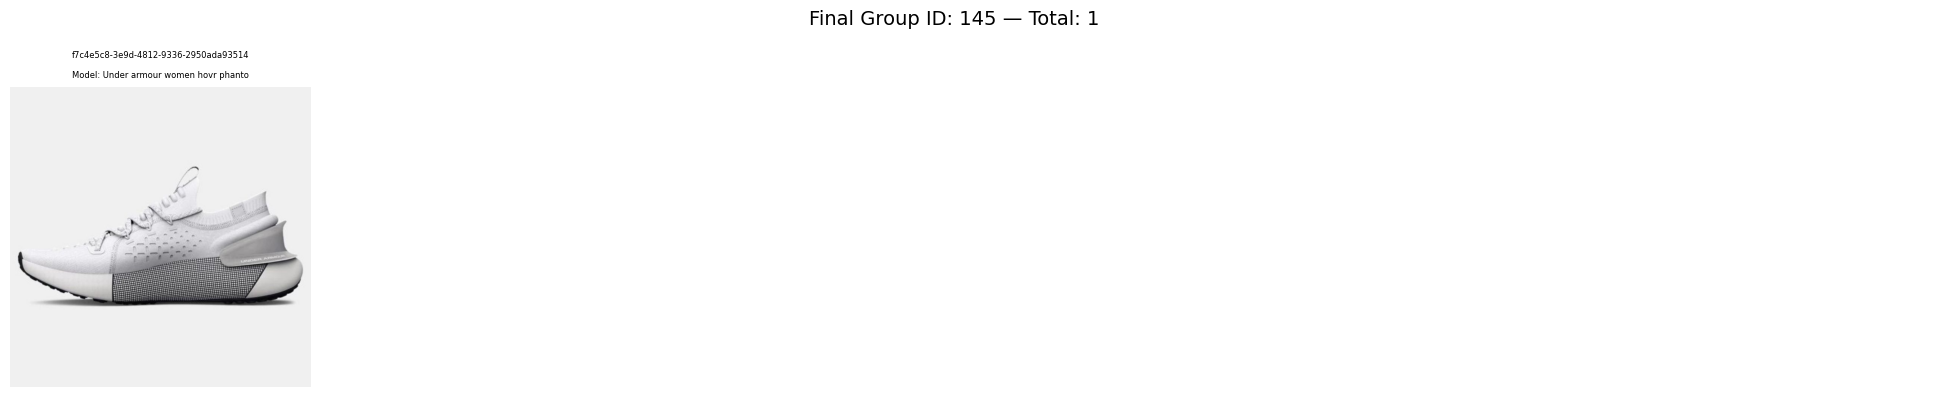

Press [Enter] to continue to the next group... 



Final Group ID: 532 — 1 products


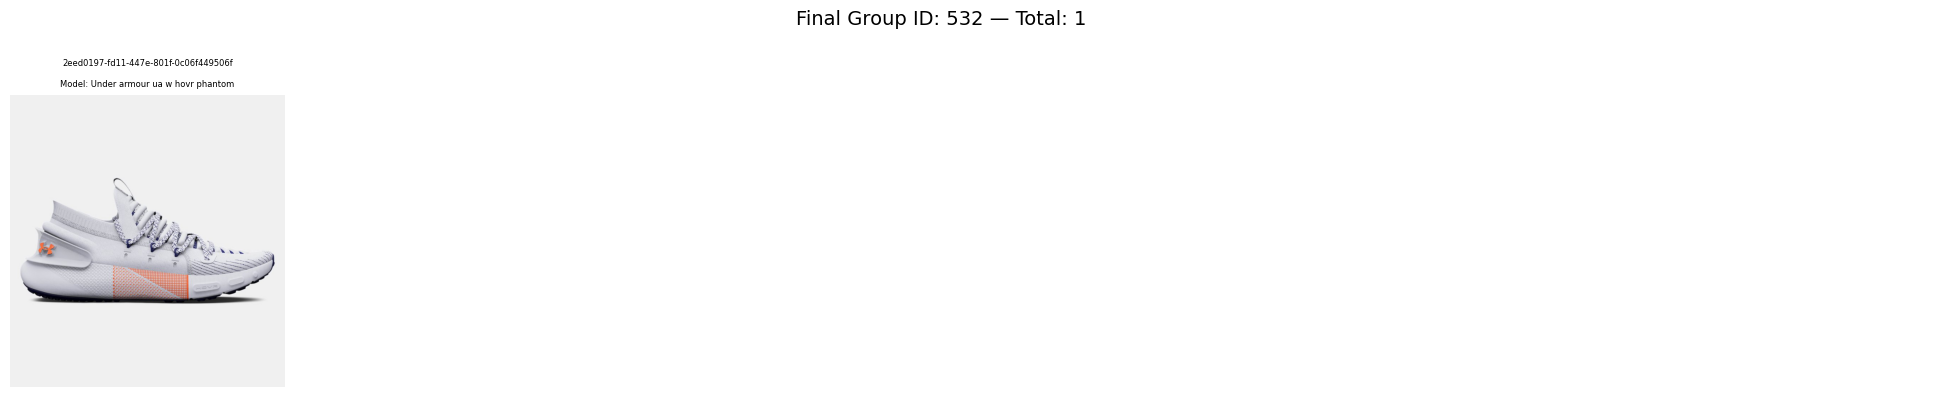

Press [Enter] to continue to the next group... 


In [118]:
# ###### use this function to display images to compare products:
# import pandas as pd
# import matplotlib.pyplot as plt
# import requests
# from PIL import Image
# from io import BytesIO
# import math
# import numpy as np

# # ✅ Step 0: Specify the exact groups you want to view
# selected_group_ids = [145, 532]

# # ✅ Step 1: Define helper to choose best image URL
# def get_best_image_url(row):
#     for col in ['mainImage.original_url', 'secondary_image_1.original_url', 'secondary_image_2.original_url']:
#         url = row.get(col)
#         if isinstance(url, str) and url.strip():
#             return url
#     return None

# # ✅ Step 2: Add selected image URL column
# df_data_clip["selected_image_url"] = df_data_clip.apply(get_best_image_url, axis=1)

# # ✅ Step 3: Display images for selected groups
# for group_id in selected_group_ids:
#     group_df = df_data_clip[df_data_clip["final_group_id_clip_strict"] == group_id]
#     print(f"\nFinal Group ID: {group_id} — {len(group_df)} products")

#     if len(group_df) == 0:
#         continue

#     n_images = len(group_df)
#     n_cols = 5
#     n_rows = math.ceil(n_images / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
#     axes = axes.flatten() if isinstance(axes, (np.ndarray, list)) else [axes]

#     valid_images = 0

#     for ax, (_, row) in zip(axes, group_df.iterrows()):
#         url = row["selected_image_url"]
#         title = str(row.get("product_title", ""))[:30]
#         model_raw = row.get("name [en_GB]", None)
#         model_str = f"Model: {model_raw[:30]}" if pd.notna(model_raw) else ""
#         pid = row.get("mirakl_product_id", "Unknown")

#         if not url:
#             ax.set_title(f"{pid}\nNo Image", fontsize=7)
#             ax.axis("off")
#             continue

#         try:
#             response = requests.get(url, timeout=15)
#             content_type = response.headers.get("Content-Type", "").lower()
#             if not any(allowed in content_type for allowed in ["image", "octet-stream"]):
#                 raise ValueError(f"URL did not return an image. Content-Type: {content_type}")

#             img_bytes = BytesIO(response.content)
#             img = Image.open(img_bytes)
#             img.verify()
#             img = Image.open(BytesIO(response.content))

#             ax.imshow(img)
#             ax.set_title(f"{pid}\n{title}\n{model_str}", fontsize=6)
#             ax.axis("off")
#             valid_images += 1

#         except Exception as e:
#             print(f"Error loading image for ID {pid}: {e}")
#             ax.set_title(f"{pid}\nError", fontsize=6)
#             ax.axis("off")

#     for ax in axes[n_images:]:
#         ax.axis("off")

#     if valid_images == 0:
#         print(f"⚠️ Skipping Group {group_id} — No valid images.")
#         plt.close(fig)
#         continue

#     plt.suptitle(f"Final Group ID: {group_id} — Total: {len(group_df)}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     input("Press [Enter] to continue to the next group...")